In [78]:
import sys
from pathlib import Path

# --- Imports
import os
from collections import Counter
import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# notebook lives in  Iracing/Notebooks/ → go up one level to reach Iracing/
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

from config import TRACK_CONFIGS, DATASETS, DRIVER_ALIAS, resolve_stint_files
from config import IRSDK_AVAILABLE, IBT_CHANNELS, build_lap_validity_table, basic_clean_and_units, assign_sectors

print(f'irsdk available  : {IRSDK_AVAILABLE}')
print(f'Tracks available : {list(TRACK_CONFIGS.keys())}')
print(f'Driver aliases   : {DRIVER_ALIAS}')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
irsdk available  : True
Tracks available : ['charlotte_roval_2025', 'summit_point']
Driver aliases   : {'Rodrigo': 'Driver A', 'Tomaz': 'Driver B', 'Morsinaldo': 'Driver C', 'Thallys': 'Driver D'}


# User Selection

In [79]:
# =========================
# USER SELECTION
# =========================

TRACK = "charlotte_roval_2025"  # options: "charlotte_roval_2025", "summit_point"
track_id = TRACK  # for display and file naming

# Use real names here — aliases are applied below for display only
DRIVER_REF  = "Tomaz"     # real name (key in DATASETS)
STINT_REF   = "stint_1"

DRIVER_TEST = "Morsinaldo"       # real name (key in DATASETS)
STINT_TEST  = "stint_2"


In [80]:
# aliases resolved from shared config
driver_a  = DRIVER_ALIAS.get(DRIVER_REF,  DRIVER_REF)
driver_b  = DRIVER_ALIAS.get(DRIVER_TEST, DRIVER_TEST)
track_id  = TRACK

# file paths via shared registry (handles single & multi-file stints)
ibt_file_A = [str(p) for p in resolve_stint_files(TRACK, DRIVER_REF,  STINT_REF)]
ibt_file_B = [str(p) for p in resolve_stint_files(TRACK, DRIVER_TEST, STINT_TEST)]

print(f'Reference : {driver_a} ({DRIVER_REF}) - {STINT_REF}   -> {len(ibt_file_A)} file(s)')
print(f'Test      : {driver_b} ({DRIVER_TEST}) - {STINT_TEST}  -> {len(ibt_file_B)} file(s)')


Reference : Driver B (Tomaz) - stint_1   -> 1 file(s)
Test      : Driver C (Morsinaldo) - stint_2  -> 1 file(s)


# Import Track Sectors Edge

In [81]:
# load track geometry from shared TRACK_CONFIGS
cfg          = TRACK_CONFIGS[TRACK]
CUSTOM_EDGES = cfg['custom_edges']
SECTOR_NAMES = cfg['sector_names']
TRACK_NAME   = cfg['track_name']

print(f'Track  : {TRACK_NAME}')
print(f'Sectors: {len(CUSTOM_EDGES) - 1}')


Track  : Charlotte Roval 2025
Sectors: 18


# 2. Data loading

Two options:

- **From `.ibt` via `irsdk`** (preferred for raw sessions).
- **From CSV** (if you already exported or `irsdk` is not available).

The notebook will try what you configured above.


In [82]:
# ═══════════════════════════════════════════════════════════════
#  Telemetry helpers — via config package (single source of truth)
# ═══════════════════════════════════════════════════════════════
# PROJECT_ROOT e sys.path já configurados na Cell 0.
# Tudo vem de config/__init__.py → ibt_loader.py

from config import (
    load_stint,
    basic_clean_and_units,
    build_lap_validity_table,
    IBT_CHANNELS,
)

# Alias backward-compat para chamadas load_from_ibt() no resto do notebook
load_from_ibt = load_stint

print("✅ helpers importados de config → ibt_loader")

# 4. Como ibt_file_A já é uma lista de strings, passamos diretamente!
raw_df = load_from_ibt(ibt_file_A)
display(raw_df.head())

✅ helpers importados de config → ibt_loader
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt … OK (179,705 samples, laps 0–28)


,Lat,Lon,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,Speed,LatAccel,LongAccel,YawRate,RPM,Gear,BrakeABSactive
0,0.000000,0.000000,59.700001,0,0.000000,0.0,0.0,1.0,0.0,-0.096121,0.000000,-0.007257,-0.064572,-0.000629,300.0,0,False
1,35.350725,-80.685287,59.716668,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.004355,0.129972,0.280290,-0.002115,300.0,0,False
2,35.350725,-80.685287,59.733334,0,0.065122,0.0,0.0,1.0,0.0,-0.096121,0.005736,-0.681544,0.591270,-0.002677,300.0,0,False
3,35.350725,-80.685287,59.750001,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.023581,-0.532607,0.959497,-0.000691,300.0,0,False
4,35.350725,-80.685287,59.766668,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.039354,-0.451288,0.910195,0.003051,300.0,0,False


# 3) Data Cleaning



In [83]:
from typing import Dict

def format_laptime(seconds: float) -> str:
    """Convert seconds to MM:SS.mmm string."""
    if pd.isna(seconds):
        return "N/A"
    minutes          = int(seconds // 60)
    remaining_seconds = seconds % 60
    return f"{minutes:02d}:{remaining_seconds:06.3f}"


def align_lap_by_dist(g: pd.DataFrame, grid: np.ndarray) -> Dict[str, np.ndarray]:
    g = g.sort_values("LapDistPct").drop_duplicates(subset=["LapDistPct"], keep="first")
    if g.empty:
        return {}

    t_rel = g["SessionTime"] - g["SessionTime"].iloc[0]
    x     = g["LapDistPct"].to_numpy()

    if len(x) < 2 or np.allclose(x.max() - x.min(), 0):
        return {}

    def interp(y: np.ndarray) -> np.ndarray:
        return np.interp(grid, x, y)

    return {
        "LapDistPct":        grid,
        "t_rel":             interp(t_rel.to_numpy()),
        "speed":             interp(g["Speed_KPH"].to_numpy()),
        "throttle":          interp(g["Throttle_Pct"].to_numpy()),
        "brake":             interp(g["Brake_Pct"].to_numpy()),
        "SteeringWheelAngle":interp(g["SteeringWheelAngle"].to_numpy()),
        "YawRate":           interp(g.get("YawRate",    pd.Series(np.zeros_like(x))).to_numpy()),
        "LongAccel":         interp(g.get("LongAccel",  pd.Series(np.zeros_like(x))).to_numpy()),
    }

In [84]:
df_ref = basic_clean_and_units(raw_df)
df_ref.head()

,Lat,Lon,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,...,YawRate,RPM,Gear,BrakeABSactive,Speed_KPH,Throttle_Pct,Brake_Pct,LatAccel_G,LongAccel_G,TotalAccel_G
0,0.000000,0.000000,59.700001,0,0.000000,0.0,0.0,1.0,0.0,-0.096121,...,-0.000629,300.0,0,False,0.000000,0.0,100.0,-0.000740,-0.006582,0.006624
1,35.350725,-80.685287,59.716668,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,...,-0.002115,300.0,0,False,0.015679,0.0,100.0,0.013249,0.028572,0.031494
2,35.350725,-80.685287,59.733334,0,0.065122,0.0,0.0,1.0,0.0,-0.096121,...,-0.002677,300.0,0,False,0.020651,0.0,100.0,-0.069474,0.060272,0.091975
3,35.350725,-80.685287,59.750001,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,...,-0.000691,300.0,0,False,0.084890,0.0,100.0,-0.054292,0.097808,0.111866
4,35.350725,-80.685287,59.766668,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,...,0.003051,300.0,0,False,0.141674,0.0,100.0,-0.046003,0.092782,0.103561



## 4. Lap validity & reference selection

We mark laps as valid and pick a **reference lap** (fastest among valid). We'll also pick a **target lap** to compare.


In [85]:
INVALID_LAPS = set()
TARGET_LAP_TO_ANALYZE = 4

lap_df = build_lap_validity_table(df_ref, manual_invalid=INVALID_LAPS)

lap_df["LapTime_Formatted"] = lap_df["LapTime_s"].apply(format_laptime)

display(lap_df[["Lap", "Valid", "LapTime_s", "LapTime_Formatted"]])

valid_laps = lap_df[lap_df["Valid"]]["Lap"].tolist()

if not valid_laps:
    raise RuntimeError("Nenhuma volta válida encontrada.")

# --- Referência: volta mais rápida válida ---
ref_row = lap_df[lap_df["Valid"]].sort_values("LapTime_s").iloc[0]
ref_lap = int(ref_row["Lap"])

# --- Target: tentativa manual com fallback ---
target_lap = TARGET_LAP_TO_ANALYZE

if target_lap not in valid_laps:
    print(
        f"⚠️ Volta alvo {target_lap} não existe ou é inválida.\n"
        f"Usando a volta válida mais lenta como fallback."
    )
    target_lap = max(valid_laps)

target_row = lap_df.loc[lap_df["Lap"] == target_lap].iloc[0]

print(f"Reference lap: {ref_lap}  ({format_laptime(ref_row['LapTime_s'])})")
print(f"Target lap   : {target_lap}  ({format_laptime(target_row['LapTime_s'])})")


──────────────────────────────────────────────────────────────
  Lap Validity Report  (29 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 25 laps
  🏆 Fastest : Lap 19  (01:36.733)
  ❌ Invalid : 4 laps
     Lap   0  48:37.467  → FracLowSpeed=0.30 | LapTime=2917.5s | GPS=95.0%<100%
     Lap   5  01:40.250  → IQR_outlier
     Lap  10  01:48.733  → IQR_outlier
     Lap  28  02:57.883  → FracLowSpeed=0.44 | LapTime=177.9s
──────────────────────────────────────────────────────────────


,Lap,Valid,LapTime_s,LapTime_Formatted
0,0,False,2917.466667,48:37.467
1,1,True,98.266667,01:38.267
2,2,True,99.416667,01:39.417
3,3,True,98.083333,01:38.083
4,4,True,97.283333,01:37.283
5,5,False,100.250000,01:40.250
6,6,True,97.933333,01:37.933
7,7,True,97.283333,01:37.283
8,8,True,99.066667,01:39.067
9,9,True,98.400000,01:38.400


Reference lap: 19  (01:36.733)
Target lap   : 4  (01:37.283)


# Import other driver telemetry

In [86]:
raw_df_test = load_from_ibt(ibt_file_B)
#Data Cleaning
df_test = basic_clean_and_units(raw_df_test)
df_test.head()

    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-01-28 15-24-41(Morsinaldo).ibt … OK (111,960 samples, laps 0–31)


,Lat,Lon,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,...,YawRate,RPM,Gear,BrakeABSactive,Speed_KPH,Throttle_Pct,Brake_Pct,LatAccel_G,LongAccel_G,TotalAccel_G
0,0.000000,0.000000,3022.499999,0,0.000000,0.0,0.0,1.0,0.499622,7.090895,...,-0.002392,300.000000,0,False,0.000000,0.0,100.0,0.104611,0.270997,0.290487
1,35.350725,-80.685287,1899.149999,14,0.065118,0.0,0.0,0.0,0.000000,0.319406,...,-0.006148,1142.602417,1,False,0.087813,0.0,0.0,0.006587,0.018291,0.019441
2,35.350725,-80.685287,1899.166666,14,0.065118,0.0,0.0,0.0,0.000000,0.319406,...,-0.006410,1132.198120,1,False,0.083922,0.0,0.0,0.006085,0.017937,0.018941
3,35.350725,-80.685287,1899.183333,14,0.065118,0.0,0.0,0.0,0.000000,0.319406,...,-0.005605,1121.791382,1,False,0.079895,0.0,0.0,0.005834,0.017785,0.018717
4,35.350725,-80.685287,1899.199999,14,0.065118,0.0,0.0,0.0,0.000000,0.319406,...,-0.003850,1111.385498,1,False,0.075576,0.0,0.0,0.006830,0.019189,0.020368


In [87]:
#Cleaning lap time
INVALID_LAPS = set()  # add warm-up, pit-in/out laps if needed
target_lap = 10 # Tentativa de usar a volta desejada


#retorna um DataFrame com a coluna 'LapTime_s'
lap_df = build_lap_validity_table(df_test, manual_invalid=INVALID_LAPS)

# 1. Adicionamos uma nova coluna ao DataFrame com o tempo formatado
lap_df['LapTime_Formatted'] = lap_df['LapTime_s'].apply(format_laptime)

valid_laps = lap_df[lap_df["Valid"]]["Lap"].tolist()

# Exibimos o DataFrame com a nova coluna para melhor visualização
display(lap_df[['Lap', 'Valid', 'LapTime_s', 'LapTime_Formatted']])

if not valid_laps:
    raise RuntimeError("Nenhuma volta válida encontrada para este piloto.")

# Volta de referência (mais rápida válida)
ref_row_test = lap_df[lap_df["Valid"]].sort_values("LapTime_s").iloc[0]
ref_lap = int(ref_row_test["Lap"])


if target_lap not in valid_laps:
    print(
        f"⚠️ Volta alvo {target_lap} não disponível para este piloto.\n"
        f"Usando a volta válida mais lenta como fallback."
    )
    target_lap = max(valid_laps)
    
target_row = lap_df[lap_df["Lap"] == target_lap].iloc[0]

print(f"Reference lap: {ref_lap}  ({format_laptime(ref_row['LapTime_s'])})")
print(f"Target lap   : {target_lap}  ({format_laptime(target_row['LapTime_s'])})")


──────────────────────────────────────────────────────────────
  Lap Validity Report  (19 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 14 laps
  🏆 Fastest : Lap 29  (01:38.417)
  ❌ Invalid : 5 laps
     Lap   0  00:00.000  → CompletedPct=0.000<0.995 | FracLowSpeed=1.00 | MaxSpeed=0.0kph | LapTime=0.0s | GPS=1.0%<100%
     Lap  14  01:57.500  → StartPct=0.065>0.02 | GPS=94.0%<100%
     Lap  22  02:03.833  → LapTime=123.8s
     Lap  24  02:22.400  → LapTime=142.4s
     Lap  31  00:10.767  → CompletedPct=0.092<0.995 | LapTime=10.8s | GPS=10.0%<100%
──────────────────────────────────────────────────────────────


,Lap,Valid,LapTime_s,LapTime_Formatted
0,0,False,0.000000,00:00.000
1,14,False,117.500000,01:57.500
2,15,True,109.900000,01:49.900
3,16,True,102.433333,01:42.433
4,17,True,99.583333,01:39.583
5,18,True,99.783333,01:39.783
6,19,True,108.200000,01:48.200
7,20,True,116.200000,01:56.200
8,21,True,99.666667,01:39.667
9,22,False,123.833333,02:03.833


⚠️ Volta alvo 10 não disponível para este piloto.
Usando a volta válida mais lenta como fallback.
Reference lap: 29  (01:36.733)
Target lap   : 30  (01:39.067)


# Tratamento dos Dados

In [88]:


# Optional irsdk (for .ibt)
try:
    import irsdk
    IRSDK_AVAILABLE = True
except Exception:
    IRSDK_AVAILABLE = False

print(f"irsdk available   : {IRSDK_AVAILABLE}")

# --- Paths & Parameters
USE_IBT = True  # set True to read a .ibt with irsdk if available

# --- Configuration ---
COL_TIME = 'SessionTime'      
COL_LAP = 'Lap'              
COL_VAR = 'Throttle_Pct'  

# Core pipeline settings
N_SECTORS = 4               # number of sectors to split the track
BASE_GRID_LEN = 1000
TOPK_PERCENT = 0.30          # robust sector reference: median of fastest top K%
PACE_THRESHOLD_MS = 3000.0   # drop laps whose sum of positive sector losses > 2s
CLIP_MS = 1500.0             # clip training target (ms)
SEQ_LEN = 128                # per-sector resampling for stability
SEED = 42



irsdk available   : True


# Análise das propriedades estatísticas

nesta seção serão analisados os dados das principais variáveis disponíveis no dataset, dentre elas estão:

* Posição do pedal do acelerador (%)
* Posição do pedal do freio (%)
* Tempo de volta
* Aceleração total

In [89]:
# =========================================================
# PROCESSAMENTO E LIMPEZA DE VOLTAS (REF vs TEST)
# =========================================================

# 1. Limpeza básica e conversão de unidades
df_ref_proc  = basic_clean_and_units(df_ref)
df_test_proc = basic_clean_and_units(df_test)

# 2. Geração das tabelas de validade nomeadas
# Aqui renomeamos para identificar quem é quem
# Aplicamos a regra de exclusão APENAS para o piloto de referência (Driver A)
laps_ref = build_lap_validity_table(df_ref_proc, manual_invalid={}, max_lap_time_s=115.0)

# O piloto de teste (Driver B) continua com a validação padrão, sem descartes manuais
laps_test = build_lap_validity_table(df_test_proc, max_lap_time_s=115.0)

# Adicionamos a coluna formatada para os relatórios da tese
laps_ref['LapTime_Formatted']      = laps_ref['LapTime_s'].apply(format_laptime)
laps_test['LapTime_Formatted'] = laps_test['LapTime_s'].apply(format_laptime)

# 3. CRIAÇÃO DOS DATAFRAMES "CLEAN" (O combustível para a análise estocástica)
# Filtramos o DataFrame original para manter APENAS as linhas de voltas válidas
df_ref_clean = df_ref_proc[
    df_ref_proc["Lap"].isin(laps_ref[laps_ref["Valid"]]["Lap"])
].copy()

df_test_clean = df_test_proc[
    df_test_proc["Lap"].isin(laps_test[laps_test["Valid"]]["Lap"])
].copy()

# --- Relatório de Conferência ---
print(f"✅ {driver_a}: {len(laps_ref[laps_ref['Valid']])} voltas válidas para análise.")
print(f"✅ {driver_b}: {len(laps_test[laps_test['Valid']])} voltas válidas para análise.")

display(laps_test[laps_test["Valid"]][['Lap', 'LapTime_Formatted']].head())

──────────────────────────────────────────────────────────────
  Lap Validity Report  (29 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 25 laps
  🏆 Fastest : Lap 19  (01:36.733)
  ❌ Invalid : 4 laps
     Lap   0  48:37.467  → FracLowSpeed=0.30 | LapTime=2917.5s | GPS=95.0%<100%
     Lap   5  01:40.250  → IQR_outlier
     Lap  10  01:48.733  → IQR_outlier
     Lap  28  02:57.883  → FracLowSpeed=0.44 | LapTime=177.9s
──────────────────────────────────────────────────────────────
──────────────────────────────────────────────────────────────
  Lap Validity Report  (19 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 12 laps
  🏆 Fastest : Lap 29  (01:38.417)
  ❌ Invalid : 7 laps
     Lap   0  00:00.000  → CompletedPct=0.000<0.995 | FracLowSpeed=1.00 | MaxSpeed=0.0kph | LapTime=0.0s | GPS=1.0%<100%
     Lap  14  01:57.500  → StartPct=0.065>0.02 | LapTime=117.5s | GPS=94.0%<100%
     Lap  20  01:56.200  → LapT

,Lap,LapTime_Formatted
2,15,01:49.900
3,16,01:42.433
4,17,01:39.583
5,18,01:39.783
6,19,01:48.200


In [90]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analyze_discrete_stationarity(df, lap_col, time_col):
    """
    Export-ready version: computes WSS statistics and
    returns the figure for external saving.
    """
    # 1. Data preparation
    lap_times = df.groupby(lap_col)['LocalLapTime'].max()
    laps  = lap_times.index
    times = lap_times.values

    mu    = np.mean(times)
    sigma = np.std(times)

    def format_time(seconds, _=None):
        m  = int(seconds // 60)
        s  = int(seconds % 60)
        ms = int((seconds - int(seconds)) * 1000)
        return f"{m:02d}:{s:02d}.{ms:03d}"

    # 2. Figure creation
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- Subplot 1: Discrete Process X_n ---
    ax1.plot(laps, times, marker='o', linestyle='-', color='royalblue',
             label=r'Lap Time $X_n$')
    ax1.axhline(mu, color='red', linestyle='--', linewidth=2,
                label=f'Mean ({format_time(mu)})')
    ax1.fill_between(laps, mu - sigma, mu + sigma, color='red', alpha=0.1,
                     label=r'$\pm 1 \sigma$')

    ax1.yaxis.set_major_formatter(FuncFormatter(format_time))
    ax1.set_title('Discrete Process: Lap Times', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Lap Number (n)', fontsize=12)
    ax1.set_ylabel('Lap Time (mm:ss.ms)', fontsize=12)
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # --- Subplot 2: PDF ---
    sns.histplot(times, kde=True, ax=ax2, bins=10, color='royalblue', edgecolor='black')
    ax2.set_title('Probability Density Function (PDF)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Lap Time (s)', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()

    # Return figure and statistics for external use
    return fig, mu, sigma

## Statísticas do tempo de volta

In [91]:
# Certifique-se de que df_ref_clean e df_test_clean já foram carregados
pilotos_analise = [
    (driver_a,  STINT_REF,  df_ref_clean), 
    (driver_b, STINT_TEST, df_test_clean)
]

# 2. Pré-processamento Robusto (Garante que todas as colunas necessárias existam)
for label, stint, df in pilotos_analise:
    if df is not None and not df.empty:
        print(f"🔄 Preparando dados: {label} ({stint})")
        
        # Ordenação cronológica fundamental para Séries Temporais
        df.sort_values(['Lap', 'SessionTime'], inplace=True)
        
        # Cálculo do Tempo Local da Volta (LocalLapTime)
        # Necessário para alinhar as voltas em 0s nos gráficos de Ciclo-Estacionariedade
        df['LocalLapTime'] = df.groupby('Lap')['SessionTime'].transform(lambda x: x - x.min())
        
        # Cálculo da Magnitude de G (TotalAccel_G)
        # Usada nos diagramas G-G e análise de Entropia
        if 'TotalAccel_G' not in df.columns:
            if 'LatAccel_G' in df.columns and 'LongAccel_G' in df.columns:
                df['TotalAccel_G'] = (df['LatAccel_G']**2 + df['LongAccel_G']**2)**0.5
            else:
                # Caso os dados estejam em m/s^2 (padrão iRacing)
                df['TotalAccel_G'] = ((df['LatAccel']/9.81)**2 + (df['LongAccel']/9.81)**2)**0.5

print("\n✅ 'pilotos_analise' definido e dados sincronizados!")

🔄 Preparando dados: Driver B (stint_1)
🔄 Preparando dados: Driver C (stint_2)

✅ 'pilotos_analise' definido e dados sincronizados!


In [92]:
def compare_cyclostationarity(df_ref, df_test, target_col, filter_zeros=False, clip_range=None):
    """
    Comparative dashboard with auto y-limits based on the 99.9th percentile
    to prevent G-force spikes from compressing the driving visualization.
    """
    # 1. SMART AXIS LIMITS
    all_values = pd.concat([df_ref[target_col], df_test[target_col]])

    # 99.9th percentile to ignore impact spikes (curbs/crashes)
    v_min  = all_values.min()
    v_max  = all_values.quantile(0.999)

    # Add a breathing margin
    margin       = (v_max - v_min) * 0.1
    unified_ylim = (max(0, v_min - (margin if v_min > 0 else 0)), v_max + margin)

    # 2. PLOT SETUP
    fig, axes = plt.subplots(2, 2, figsize=(20, 15), gridspec_kw={'height_ratios': [2, 1]})

    drivers = [
        (df_ref,  driver_a, STINT_REF,  0),
        (df_test, driver_b, STINT_TEST, 1),
    ]

    for df, name, stint, col in drivers:
        if df is None or df.empty:
            continue

        # --- TOP PLOT: Ensemble Mean ---
        ax_top = axes[0, col]
        sns.lineplot(data=df, x='LocalLapTime', y=target_col, hue='Lap',
                     palette='viridis', linewidth=0.4, alpha=0.3, legend=None, ax=ax_top)

        # Ensemble mean
        df_calc        = df.copy()
        df_calc['TimeBin'] = df_calc['LocalLapTime'].round(1)
        ensemble_mean  = df_calc.groupby('TimeBin')[target_col].mean()

        ax_top.plot(ensemble_mean.index, ensemble_mean.values, color='red',
                    linewidth=2.5, label=r'Ensemble Mean $E[X(t)]$')

        # Apply synchronized auto-zoom
        ax_top.set_ylim(unified_ylim)
        ax_top.set_title(f'{name} ({stint})\n{target_col}: Cyclo-Stationary Profile',
                         fontsize=15, fontweight='bold')
        ax_top.set_xlabel('Time in Lap (s)')
        ax_top.set_ylabel(f'{target_col}')
        ax_top.grid(True, linestyle=':', alpha=0.6)
        ax_top.legend(loc='upper right')

        # --- BOTTOM PLOT: PDF per Lap ---
        ax_bottom  = axes[1, col]
        plot_data  = df.copy()
        if filter_zeros:
            plot_data = plot_data[plot_data[target_col] > (v_max * 0.01)]  # 1% of max to filter noise

        sns.kdeplot(data=plot_data, x=target_col, hue='Lap', ax=ax_bottom,
                    palette='viridis', alpha=0.3, linewidth=1.2,
                    common_norm=False, legend=False, clip=clip_range)

        # Sync PDF x-axis with top plot y-axis
        ax_bottom.set_xlim(unified_ylim)
        ax_bottom.set_title('Strict-Sense Stationarity (Density)', fontsize=13)
        ax_bottom.set_xlabel(f'{target_col} value')
        ax_bottom.grid(True, linestyle=':', alpha=0.6)

    # Spacing adjustment to avoid clipping titles
    plt.subplots_adjust(top=0.92, bottom=0.08, hspace=0.3, wspace=0.2)

    # 3. SAVE
    file_name = (
    f"cyclostationarity_{target_col.lower()}"
    f"_{driver_a}_{STINT_REF}_vs_{driver_b}_{STINT_TEST}_{track_id}.png")
    fig.savefig(Path(SAVE_DIR) / file_name, dpi=300, bbox_inches='tight')


def analyze_cyclostationarity(df, target_col, filter_zeros=False, clip_range=None):
    """
    Visualizes Cyclo-Stationarity (Top) and Strict-Sense Stationarity (Bottom).

    Args:
        filter_zeros (bool): If True, filters out values <= 1.0 in the PDF plot
                             to analyze the 'active usage' shape (useful for Brakes).
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10),
                                   gridspec_kw={'height_ratios': [2, 1]})

    # --- PLOT 1: Time Series Ensemble (TOP) ---
    sns.lineplot(data=df, x='LocalLapTime', y=target_col,
                 hue=COL_LAP, palette='viridis',
                 linewidth=0.5, alpha=0.5, legend=None, ax=ax1)

    # Ensemble mean
    df_calc            = df.copy()
    df_calc['TimeBin'] = df_calc['LocalLapTime'].round(1)
    ensemble_mean      = df_calc.groupby('TimeBin')[target_col].mean()

    ax1.plot(ensemble_mean.index, ensemble_mean.values,
             color='red', linewidth=2.5, label=r'Ensemble Mean $E[X(t)]$')

    ax1.set_title(f'Cyclo-Stationary Process: {target_col} (Ensemble)', fontsize=14)
    ax1.set_xlabel('Time since Lap Start (s)', fontsize=12)
    ax1.set_ylabel(target_col, fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # --- PLOT 2: Strict-Sense PDF (BOTTOM) ---
    plot_data    = df.copy()
    title_suffix = ""

    if filter_zeros:
        print(f"[FILTER] Removing values <= 1.0 to analyse active usage shape...")
        plot_data    = plot_data[plot_data[target_col] > 1.0]
        title_suffix = " (Active Usage Only > 1%)"

    sns.kdeplot(data=plot_data, x=target_col, hue=COL_LAP, ax=ax2,
                palette='viridis', alpha=0.3, linewidth=1.5,
                common_norm=False, legend=False,
                clip=clip_range)  # Physical sensor limit

    ax2.set_title(f'Strict-Sense Stationarity Check: PDF per Lap{title_suffix}', fontsize=14)
    ax2.set_xlabel(f'{target_col} Value', fontsize=12)
    ax2.set_ylabel('Density', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [93]:
# ── Output directory — mirrors lap time notebook structure ─────────
PROJECT_ROOT = Path.home() / "OneDrive/Documents/GitHub/Doutorado/Racing4all"
BASE_IMG_DIR = Path(PROJECT_ROOT) / "Iracing" / "img"

COMPARISON_ID = f"{TRACK}_{driver_a}_vs_{driver_b}"
SAVE_DIR = BASE_IMG_DIR / TRACK / COMPARISON_ID / "entropy_analysis"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {SAVE_DIR}")


Output directory: C:\Users\PC\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\charlotte_roval_2025\charlotte_roval_2025_Driver B_vs_Driver C\entropy_analysis


📊 Analisando Estacionariedade: Driver B (stint_1)
✅ Gráfico salvo em: C:\Users\PC\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\charlotte_roval_2025\charlotte_roval_2025_Driver B_vs_Driver C\entropy_analysis\gg_dynamics_driver c_stint_1_charlotte_roval_2025.png


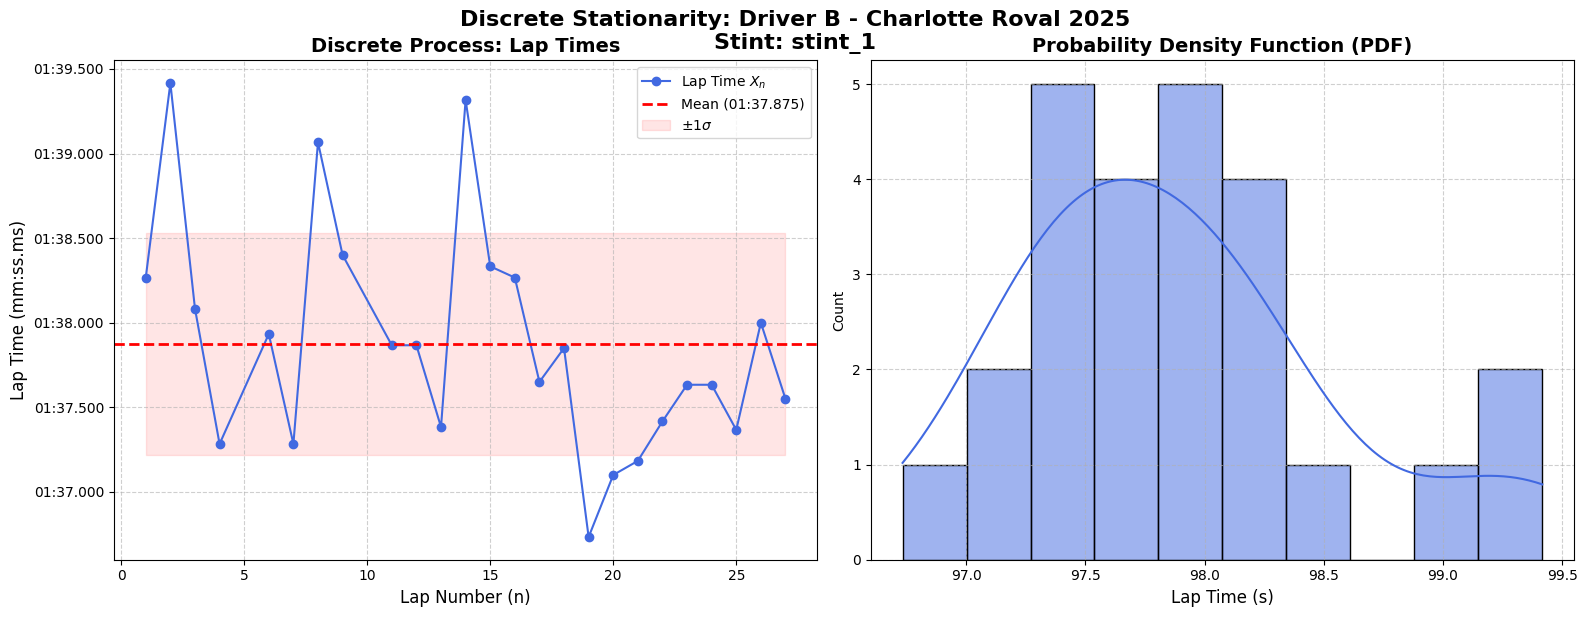

   > Média: 97.875s | Desvio Padrão: 0.657s

📊 Analisando Estacionariedade: Driver C (stint_2)
✅ Gráfico salvo em: C:\Users\PC\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\charlotte_roval_2025\charlotte_roval_2025_Driver B_vs_Driver C\entropy_analysis\gg_dynamics_driver c_stint_1_charlotte_roval_2025.png


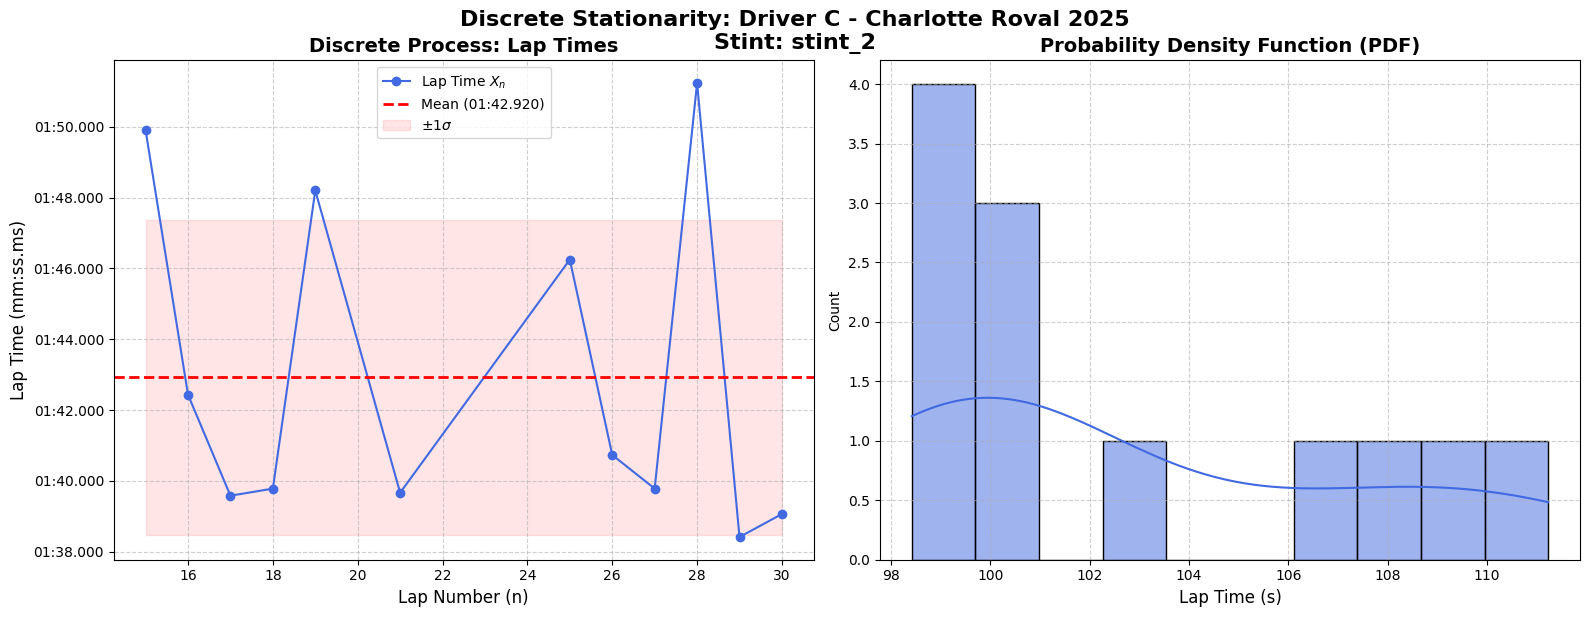

   > Média: 102.921s | Desvio Padrão: 4.457s



In [94]:
# Lista de pilotos para processar (Referência e Teste)
pilotos_para_analise = [
    (driver_a,  STINT_REF,  df_ref_clean),
    (driver_b, STINT_TEST, df_test_clean)
]

for label, stint, df in pilotos_para_analise:
    if df is None or df.empty:
        continue
        
    print(f"📊 Analisando Estacionariedade: {label} ({stint})")
    
    # 1. Gera o gráfico usando a função atualizada
    fig, mu, sigma = analyze_discrete_stationarity(df, COL_LAP, COL_TIME)
    
    # 2. Adiciona um título superior para identificar o piloto
    fig.suptitle(f"Discrete Stationarity: {label} - {TRACK_NAME}\nStint: {stint}", 
                 fontsize=16, fontweight='bold', y=1.02)
    
    # 3. Define o caminho de salvamento
    #file_name = f"stationarity_{label.lower()}_{stint.lower()}_{track_id}.png"
    #save_path = SAVE_DIR / file_name
    
    # Garante que a pasta existe
    #save_path.parent.mkdir(parents=True, exist_ok=True)
    
    # 4. Salva antes de mostrar (para não perder o objeto da figura)
    #fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Gráfico salvo em: {save_path}")
    
    # 5. Exibe no Jupyter
    plt.show()
    
    # Print dos resultados numéricos no console
    print(f"   > Média: {mu:.3f}s | Desvio Padrão: {sigma:.3f}s\n")

# Acelerações Logitudinais e Laterais

Estão disponíveis no dataset de corrida os valores de acelerações longitudinais (eixo x do carro) e laterais (eixo y). Os valores máximos de acelerações estão limitados dentro do chamado círculo G-G que é função da dinâmica veícular do veículos. Alguns fatores são pertinentes para suportar maiores forças G's:

* Tipo de pneu
* Arquitetura de suspensão
* peso do veículo

Para calcularmos a "aceleração geral" do veículo, será utilizado a soma vetorial das duas componentes, sendo assim:

$Acc = \sqrt{A_x^2 + A_y^2}$

📸 Processando Diagrama G-G: Driver B (stint_1)


<>:63: SyntaxWarning: invalid escape sequence '\s'
<>:63: SyntaxWarning: invalid escape sequence '\s'
C:\Users\PC\AppData\Local\Temp\ipykernel_22160\516263992.py:63: SyntaxWarning: invalid escape sequence '\s'
  ax2.set_title(f'Distribuição de Carga Combinada ($A = \sqrt{{A_x^2 + A_y^2}}$)', fontsize=15, fontweight='bold')


✅ Salvo em: C:\Users\PC\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\charlotte_roval_2025\charlotte_roval_2025_Driver B_vs_Driver C\entropy_analysis\gg_dynamics_driver b_stint_1_charlotte_roval_2025.png


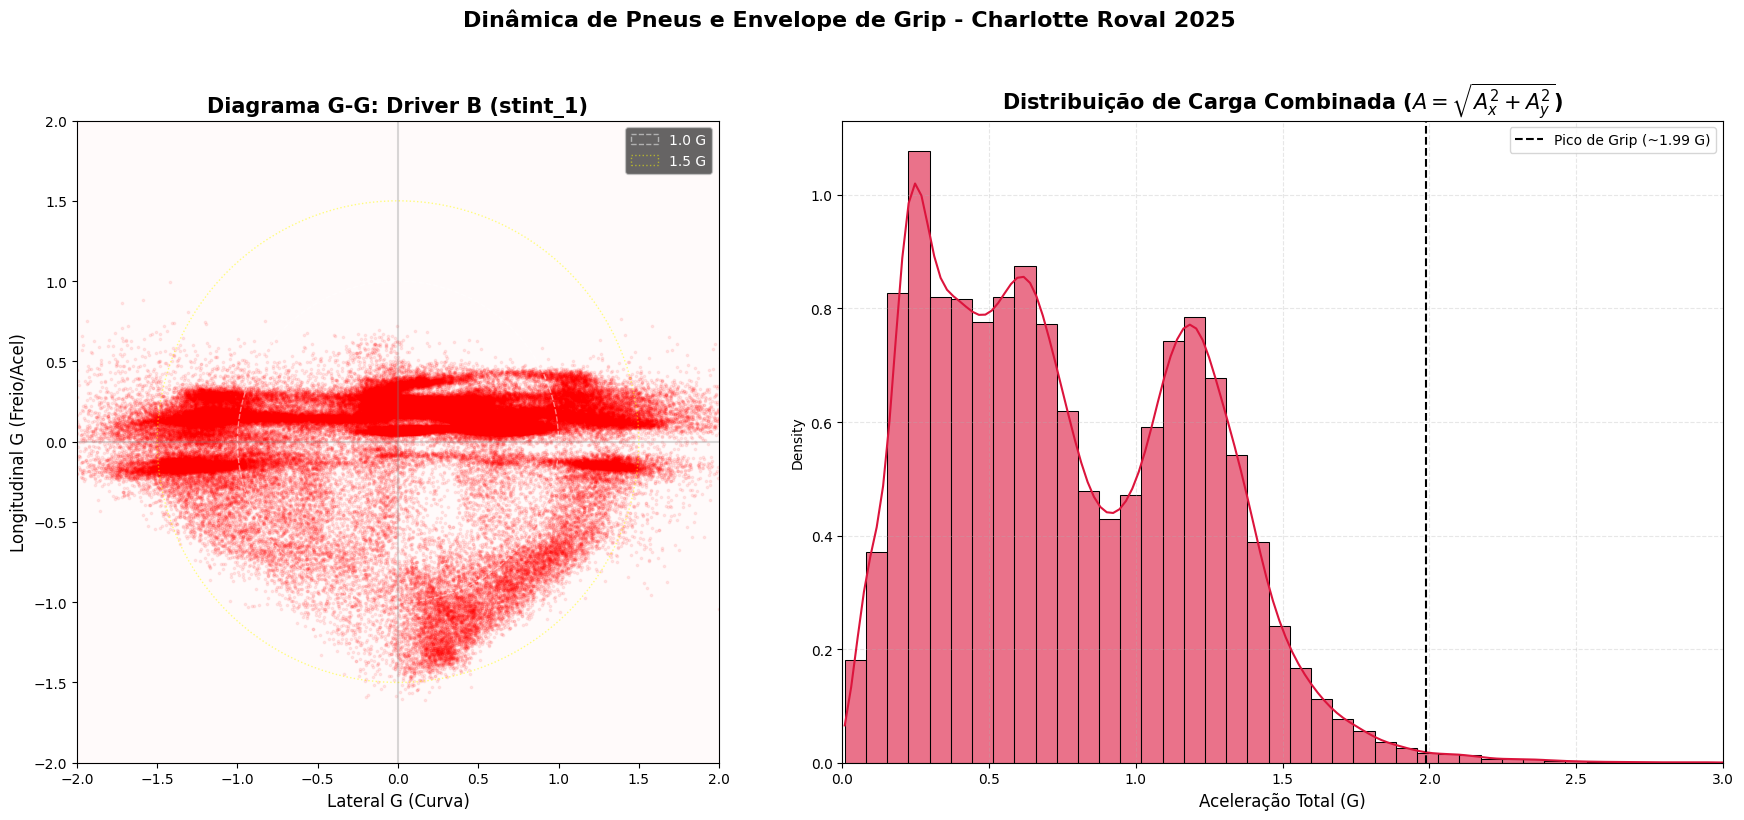

📸 Processando Diagrama G-G: Driver C (stint_2)
✅ Salvo em: C:\Users\PC\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\charlotte_roval_2025\charlotte_roval_2025_Driver B_vs_Driver C\entropy_analysis\gg_dynamics_driver c_stint_2_charlotte_roval_2025.png


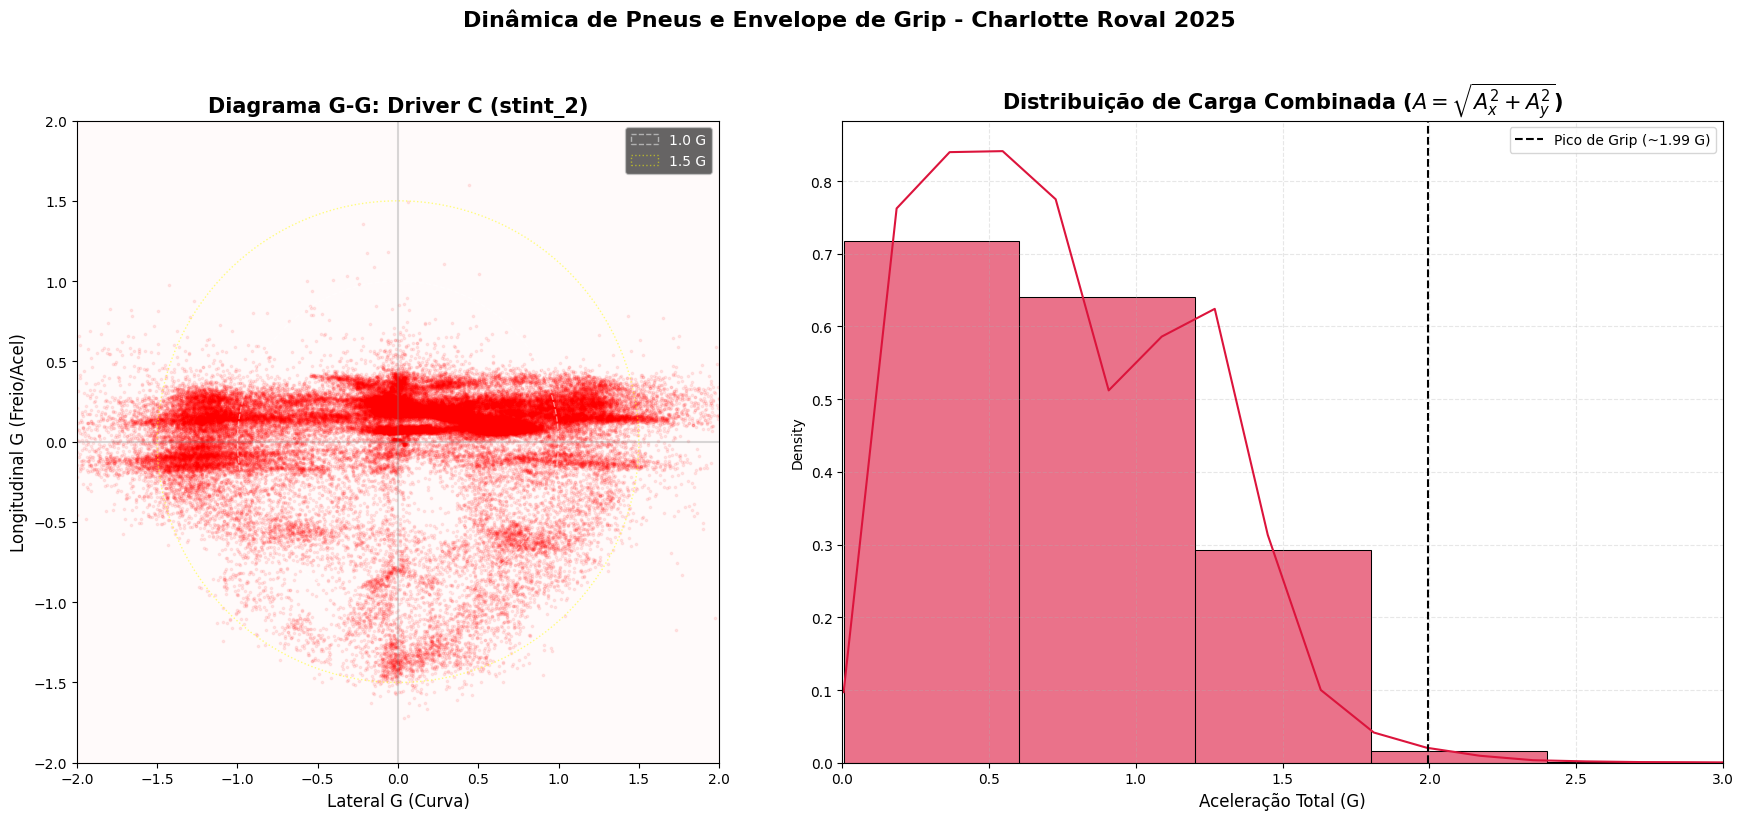

In [95]:
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

def analyze_gg_dynamics(df, label, stint, lat_col='LatAccel_G', long_col='LongAccel_G'):
    """
    Visualiza o Círculo de Fricção (G-G) e a Distribuição de Carga Total.
    Mantém o nome original, mas utiliza Scatter Plot com transparência para 
    revelar a densidade estocástica da pilotagem.
    """
    df = df.copy()
    
    # 1. Garantia de Unidades (m/s² para G)
    for col, axis in [(lat_col, 'LatAccel'), (long_col, 'LongAccel')]:
        if col not in df.columns and axis in df.columns:
            df[col] = df[axis] / 9.81
            
    # Cálculo da Aceleração Resultante (Carga Total)
    total_col = 'TotalAccel_G'
    df[total_col] = np.sqrt(df[lat_col]**2 + df[long_col]**2)

    # 2. Configuração do Layout
    fig = plt.figure(figsize=(18, 8))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.2])

    # --- PLOT 1: Diagrama G-G (Scatter Cloud) ---
    ax1 = fig.add_subplot(gs[0])
    ax1.set_facecolor("#fffafa") # Fundo escuro para destacar a nuvem
    
    # Plot de dispersão com alta transparência (alpha) para ver a densidade
    ax1.scatter(df[lat_col], df[long_col], alpha=0.08, s=3, color='red', rasterized=True)
    
    # Círculos de Referência (Envelope de Grip)
    for g_val, color, ls in [(1.0, 'white', '--'), (1.5, 'yellow', ':')]:
        circle = plt.Circle((0, 0), g_val, color=color, fill=False, 
                            linestyle=ls, alpha=0.5, label=f'{g_val} G')
        ax1.add_patch(circle)

    # Ajuste de Escala Quadrada (Crucial para G-G)
    limit = 2
    ax1.set_xlim(-limit, limit)
    ax1.set_ylim(-limit, limit)
    ax1.set_aspect('equal')
    
    ax1.axhline(0, color='gray', linestyle='-', alpha=0.3)
    ax1.axvline(0, color='gray', linestyle='-', alpha=0.3)
    
    ax1.set_title(f'Diagrama G-G: {label} ({stint})', fontsize=15, fontweight='bold')
    ax1.set_xlabel('Lateral G (Curva)', fontsize=12)
    ax1.set_ylabel('Longitudinal G (Freio/Acel)', fontsize=12)
    ax1.legend(loc='upper right', facecolor='black', labelcolor='white', framealpha=0.6)

    # --- PLOT 2: Distribuição de Carga Total ---
    ax2 = fig.add_subplot(gs[1])
    sns.histplot(df[total_col], bins=60, kde=True, ax=ax2, color='crimson', stat='density', alpha=0.6)
    
    # Pico de Grip (Percentil 99.5 para evitar ruído de impacto)
    max_g = df[total_col].quantile(0.995)
    ax2.axvline(max_g, color='black', linestyle='--', label=f'Pico de Grip (~{max_g:.2f} G)')
    
    ax2.set_title(f'Distribuição de Carga Combinada ($A = \sqrt{{A_x^2 + A_y^2}}$)', fontsize=15, fontweight='bold')
    ax2.set_xlabel('Aceleração Total (G)', fontsize=12)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.3)
    ax2.set_xlim(0, 3.0)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

# =========================================================
# EXECUÇÃO COMPARATIVA (REF vs TEST)
# =========================================================

for label, stint, df_clean in [ (driver_a, STINT_REF, df_ref_clean), 
                                (driver_b, STINT_TEST, df_test_clean)]:
    
    if df_clean is None or df_clean.empty: continue
        
    print(f"📸 Processando Diagrama G-G: {label} ({stint})")
    
    # Chama a função (mantendo o nome original)
    fig = analyze_gg_dynamics(df_clean, label, stint)
    
    # Título Global
    fig.suptitle(f"Dinâmica de Pneus e Envelope de Grip - {TRACK_NAME}", 
                 fontsize=16, fontweight='bold', y=1.02)

    # Salvamento Padronizado
    file_name = f"gg_dynamics_{label.lower()}_{stint.lower()}_{track_id}.png"
    save_path = SAVE_DIR / file_name
    
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Salvo em: {save_path}")
    
    plt.show()

# ENTROPIA

📐 Calculando ranges globais a partir de todos os stints...
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt … OK (179,705 samples, laps 0–28)
  ✅ charlotte_roval_2025 | Tomaz | stint_1
    [1/2] Loading mx5 mx52016_charlotte 2025 roval2025 2026-03-01 17-16-27.ibt … OK (100,476 samples, laps 0–16)
    [2/2] Loading mx5 mx52016_charlotte 2025 roval2025 2026-03-01 16-20-04.ibt … OK (148,787 samples, laps 17–40)
  ✅ charlotte_roval_2025 | Tomaz | stint_2
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-05-11 22-43-15.ibt … OK (64,277 samples, laps 0–9)
  ✅ charlotte_roval_2025 | Tomaz | stint_3
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-05-11 23-11-08.ibt … OK (55,207 samples, laps 0–9)
  ✅ charlotte_roval_2025 | Tomaz | stint_4
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-01-27 16-13-55(Morsinaldo).ibt … OK (121,637 samples, laps 7–26)
  ✅ charlotte_roval_2025 | Morsinaldo | stint_1
    [1/1] Loading mx5 mx52016_char

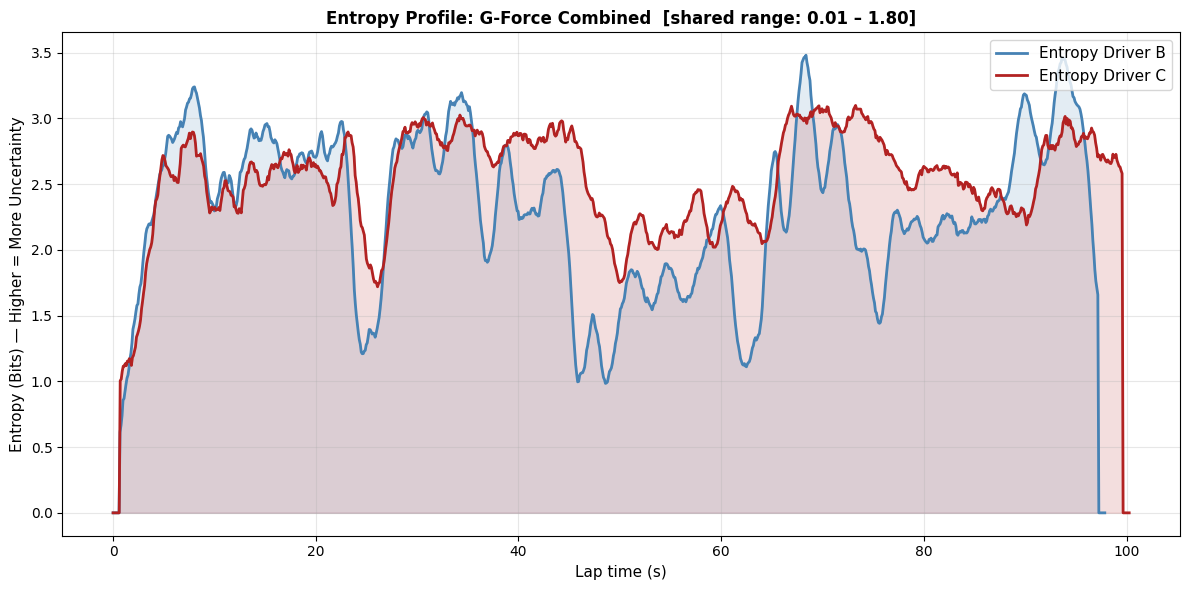

🧬 Calculando Entropia de Shannon ($H$) para: SteeringWheelAngle


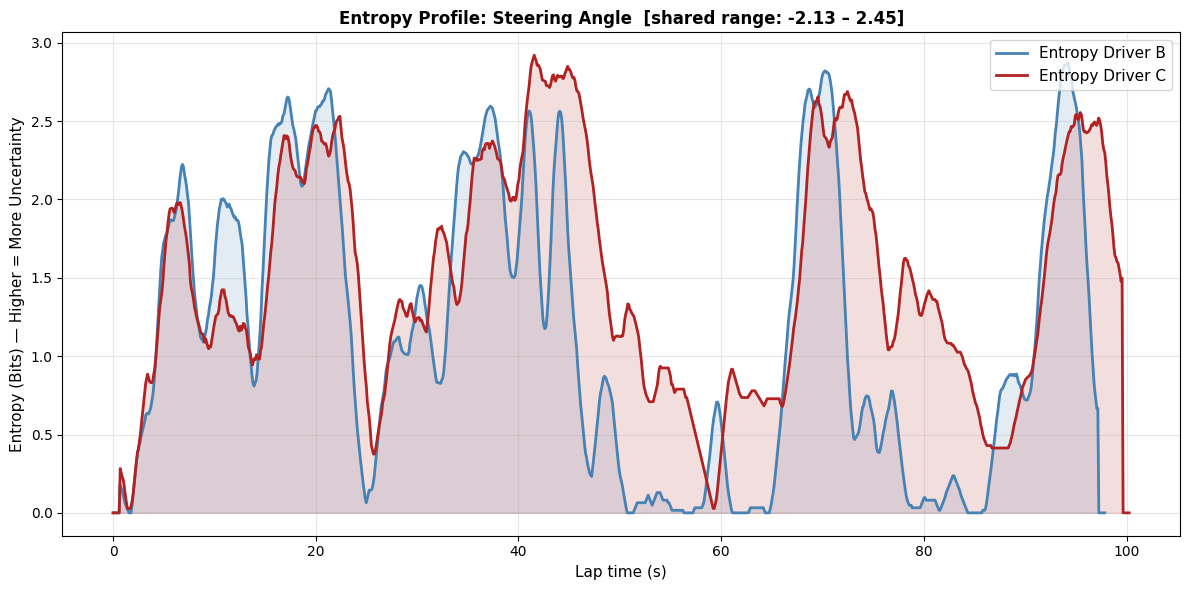

🧬 Calculando Entropia de Shannon ($H$) para: Throttle_Pct


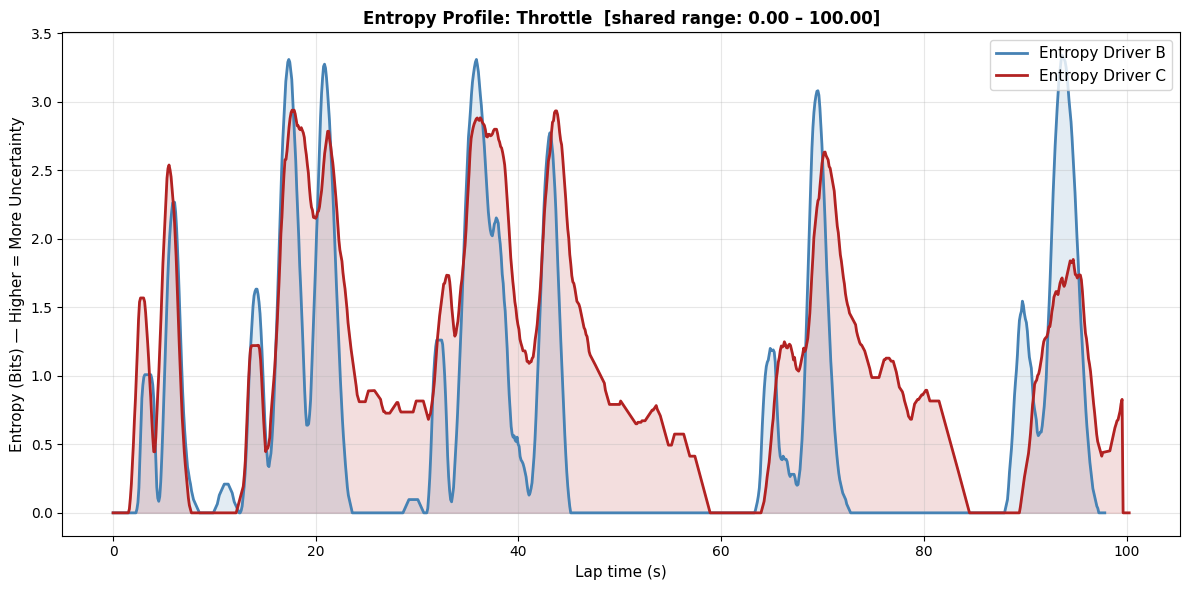

🧬 Calculando Entropia de Shannon ($H$) para: Brake_Pct


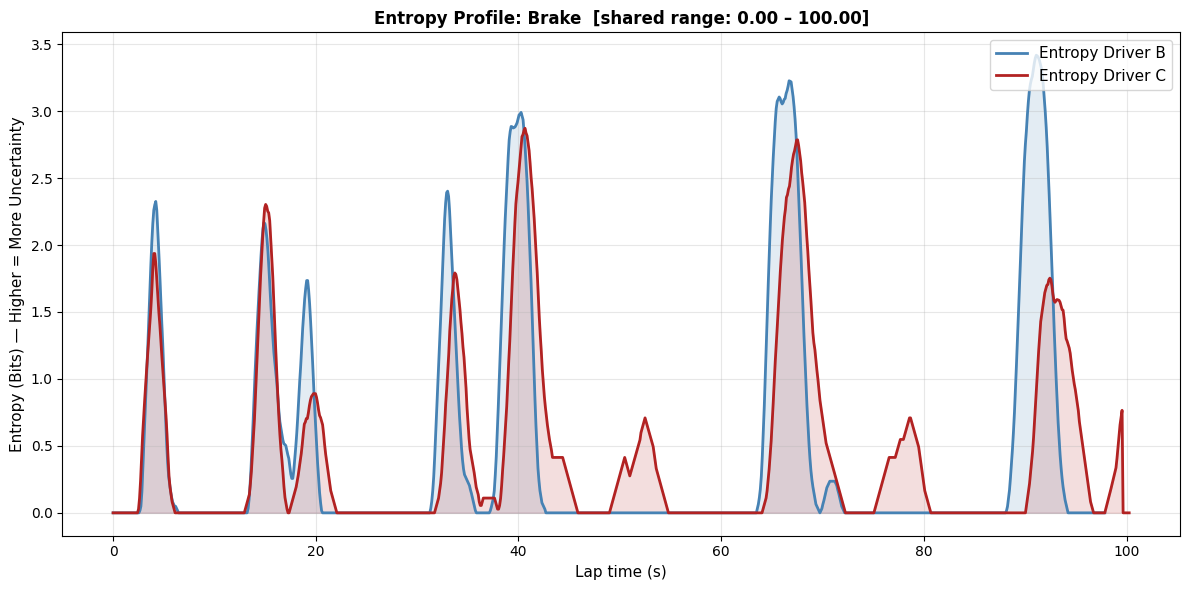

In [96]:
from scipy.stats import entropy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_comparative_entropy(df_ref, df_test, target_col, y_label,
                             bins=20, smooth_window=15,
                             global_range=None):
    """
    Calcula e compara o perfil de Entropia de Shannon ao longo da volta.
    Usa um range global compartilhado para garantir comparabilidade entre drivers.
    """
    print(f"🧬 Calculando Entropia de Shannon ($H$) para: {target_col}")

    # ── RANGE GLOBAL ─────────────────────────────────────────────────────────
    if global_range is None:
        combined = pd.concat([df_ref[target_col], df_test[target_col]], ignore_index=True)
        v_min = np.percentile(combined, 1)
        v_max = np.percentile(combined, 99)
    else:
        v_min, v_max = global_range
    # ─────────────────────────────────────────────────────────────────────────

    def get_entropy_profile(df):
        if df is None or df.empty:
            return None, None, None

        lap_times = df.groupby('Lap')['SessionTime'].apply(
            lambda x: x.max() - x.min()
        )
        common_time = np.linspace(0, lap_times.median(), 1000)

        ensemble_matrix = []
        for lap in df['Lap'].unique():
            lap_data = df[df['Lap'] == lap].sort_values('SessionTime')
            if len(lap_data) > 10:
                t_zeroed = lap_data['SessionTime'] - lap_data['SessionTime'].iloc[0]
                signal_values = lap_data[target_col].values
                interp_signal = np.interp(
                    common_time, t_zeroed, signal_values, right=np.nan
                )
                ensemble_matrix.append(interp_signal)

        if not ensemble_matrix:
            return None, None, None

        ensemble_matrix = np.array(ensemble_matrix)

        h_profile = []
        for t_idx in range(ensemble_matrix.shape[1]):
            slice_data = ensemble_matrix[:, t_idx]
            slice_data = slice_data[~np.isnan(slice_data)]

            if len(slice_data) > 2:
                counts, _ = np.histogram(
                    slice_data, bins=bins,
                    range=(v_min, v_max),
                    density=True
                )
                counts += 1e-10
                h = entropy(counts, base=2)
                h_profile.append(h)
            else:
                h_profile.append(0)

        h_series = pd.Series(h_profile)
        h_smooth = h_series.rolling(window=smooth_window, center=True).mean().fillna(0)
        mean_signal = np.nanmean(ensemble_matrix, axis=0)

        return common_time, h_smooth, mean_signal

    t_ref,  h_ref,  m_ref  = get_entropy_profile(df_ref)
    t_test, h_test, m_test = get_entropy_profile(df_test)

    fig, ax = plt.subplots(1, 1, figsize=(12, 6))

    if h_ref is not None:
        ax.plot(t_ref,  h_ref,  color='steelblue', linewidth=2, label=f'Entropy {driver_a}')
        ax.fill_between(t_ref,  0, h_ref,  color='steelblue', alpha=0.15)
    if h_test is not None:
        ax.plot(t_test, h_test, color='firebrick', linewidth=2, label=f'Entropy {driver_b}')
        ax.fill_between(t_test, 0, h_test, color='firebrick', alpha=0.15)

    ax.set_ylabel('Entropy (Bits) — Higher = More Uncertainty', fontsize=11)
    ax.set_xlabel('Lap time (s)', fontsize=11)
    ax.set_title(
        f'Entropy Profile: {y_label}  [shared range: {v_min:.2f} – {v_max:.2f}]',
        fontsize=12, fontweight='bold'
    )
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=11)

    plt.tight_layout()

    # Tenta usar as variáveis globais, se existirem (assumindo que foram definidas antes)
    try:
        file_name = (
            f"entropy_profile_{target_col.lower()}"
            f"_{driver_a}_{STINT_REF}_vs_{driver_b}_{STINT_TEST}_{TRACK}.png"
        )
        plt.savefig(SAVE_DIR / file_name, dpi=300, bbox_inches='tight')
    except NameError:
        print("Aviso: Variáveis de salvamento não definidas. O gráfico não será salvo no disco.")
        
    plt.show()


# =========================================================
# RANGE GLOBAL — calculado UMA VEZ a partir de TODOS os
# stints/drivers/pistas disponíveis no DATASETS
# =========================================================

def compute_global_ranges(datasets: dict, variables: list,
                          track_filter: str = None,
                          lower_pct: float = 1,
                          upper_pct: float = 99) -> dict:
    
    col_values = {col: [] for col, _ in variables}

    for track_key, track_info in datasets.items():
        if track_filter is not None and track_key != track_filter:
            continue
        
        base_path = Path(track_info["base_path"])
        for pilot, stints in track_info["sessions"].items():
            for stint_key, filenames in stints.items():
                
                # ─── AJUSTE PRINCIPAL AQUI ──────────────────────────────────
                # 1. Garante que filenames é sempre uma lista
                if isinstance(filenames, str):
                    filenames = [filenames]
                
                # 2. Cria uma lista de caminhos completos juntando o base_path
                filepaths = [base_path / f for f in filenames]
                # ────────────────────────────────────────────────────────────
                
                try:
                    # 3. Passa a lista de caminhos para a função
                    df_raw = load_from_ibt(filepaths)
                    
                    if df_raw.empty:
                        continue
                        
                    df_tmp = basic_clean_and_units(df_raw)
                    
                    if 'TotalAccel_G' not in df_tmp.columns:
                        df_tmp['TotalAccel_G'] = np.sqrt(
                            (df_tmp['LatAccel'] / 9.81) ** 2 +
                            (df_tmp['LongAccel'] / 9.81) ** 2
                        )
                    for col, _ in variables:
                        if col in df_tmp.columns:
                            col_values[col].append(df_tmp[col].dropna().values)
                            
                    print(f"  ✅ {track_key} | {pilot} | {stint_key}")
                except Exception as e:
                    print(f"  ⚠️  {track_key} | {pilot} | {stint_key} — {e}")

    global_ranges = {}
    for col, _ in variables:
        if col_values[col]:
            all_vals = np.concatenate(col_values[col])
            v_min = np.percentile(all_vals, lower_pct)
            v_max = np.percentile(all_vals, upper_pct)
            global_ranges[col] = (v_min, v_max)
            print(f"  Range '{col}': [{v_min:.3f} — {v_max:.3f}]")
        else:
            print(f"  ⚠️  Sem dados para '{col}'")

    return global_ranges


variaveis_entropia = [
    ('TotalAccel_G',       'G-Force Combined'),
    ('SteeringWheelAngle', 'Steering Angle'),
    ('Throttle_Pct',       'Throttle'),
    ('Brake_Pct',          'Brake'),
]

print("📐 Calculando ranges globais a partir de todos os stints...")

global_ranges = compute_global_ranges(
    DATASETS, 
    variaveis_entropia,
    track_filter=TRACK   # usa a variável já definida no notebook
)

# Loop de comparação — usa sempre o mesmo range fixo
for col, label in variaveis_entropia:
    if col in df_ref_clean.columns:
        plot_comparative_entropy(
            df_ref_clean, df_test_clean,
            col, label,
            global_range=global_ranges.get(col)
        )

# Joint Entropy - Trail Braking

In [97]:
# =========================================================
# ENTROPIA CONJUNTA — FREIO x VOLANTE (Trail Braking)
# =========================================================
from scipy.stats import entropy as joint_entropy_calc

def compute_joint_entropy_brake_steer(df, brake_range, steer_range, bins=20):
    """
    Calcula H(Freio, Volante) via histograma 2D e a Informação Mútua
    I(Freio, Volante) = H(Freio) + H(Volante) - H(Freio, Volante).
    Usa ranges globais fixos (mesma convenção do resto do notebook).
    """
    brake = df['Brake_Pct'].dropna().values
    steer = df['SteeringWheelAngle'].dropna().values
    n = min(len(brake), len(steer))
    brake, steer = brake[:n], steer[:n]

    # Histograma conjunto 2D
    hist2d, _, _ = np.histogram2d(
        brake, steer, bins=bins,
        range=[brake_range, steer_range],
        density=True
    )
    p_joint = hist2d / hist2d.sum()
    h_joint = joint_entropy_calc(p_joint.flatten() + 1e-10, base=2)

    # Marginais (para Informação Mútua)
    counts_b, _ = np.histogram(brake, bins=bins, range=brake_range, density=True)
    counts_s, _ = np.histogram(steer, bins=bins, range=steer_range, density=True)
    h_brake = joint_entropy_calc(counts_b + 1e-10, base=2)
    h_steer = joint_entropy_calc(counts_s + 1e-10, base=2)

    mutual_info = h_brake + h_steer - h_joint

    return h_joint, h_brake, h_steer, mutual_info, hist2d

In [98]:
# --- EXECUÇÃO: comparação Driver A (ref) vs Driver B (test) ---
brake_range = global_ranges.get('Brake_Pct', (0, 100))
steer_range = global_ranges.get('SteeringWheelAngle')

results_joint = {}
for label, stint, df in [(driver_a, STINT_REF, df_ref_clean),
                          (driver_b, STINT_TEST, df_test_clean)]:
    h_joint, h_b, h_s, mi, hist2d = compute_joint_entropy_brake_steer(
        df, brake_range, steer_range, bins=20
    )
    results_joint[label] = dict(h_joint=h_joint, h_brake=h_b, h_steer=h_s, mi=mi, hist2d=hist2d)
    print(f"{label} ({stint}):")
    print(f"   H(Freio, Volante) = {h_joint:.4f} bits")
    print(f"   H(Freio) = {h_b:.4f} | H(Volante) = {h_s:.4f}")
    print(f"   Informação Mútua I(Freio;Volante) = {mi:.4f} bits\n")

Driver B (stint_1):
   H(Freio, Volante) = 3.9351 bits
   H(Freio) = 1.0465 | H(Volante) = 2.9403
   Informação Mútua I(Freio;Volante) = 0.0517 bits

Driver C (stint_2):
   H(Freio, Volante) = 3.8064 bits
   H(Freio) = 0.9737 | H(Volante) = 2.8851
   Informação Mútua I(Freio;Volante) = 0.0524 bits



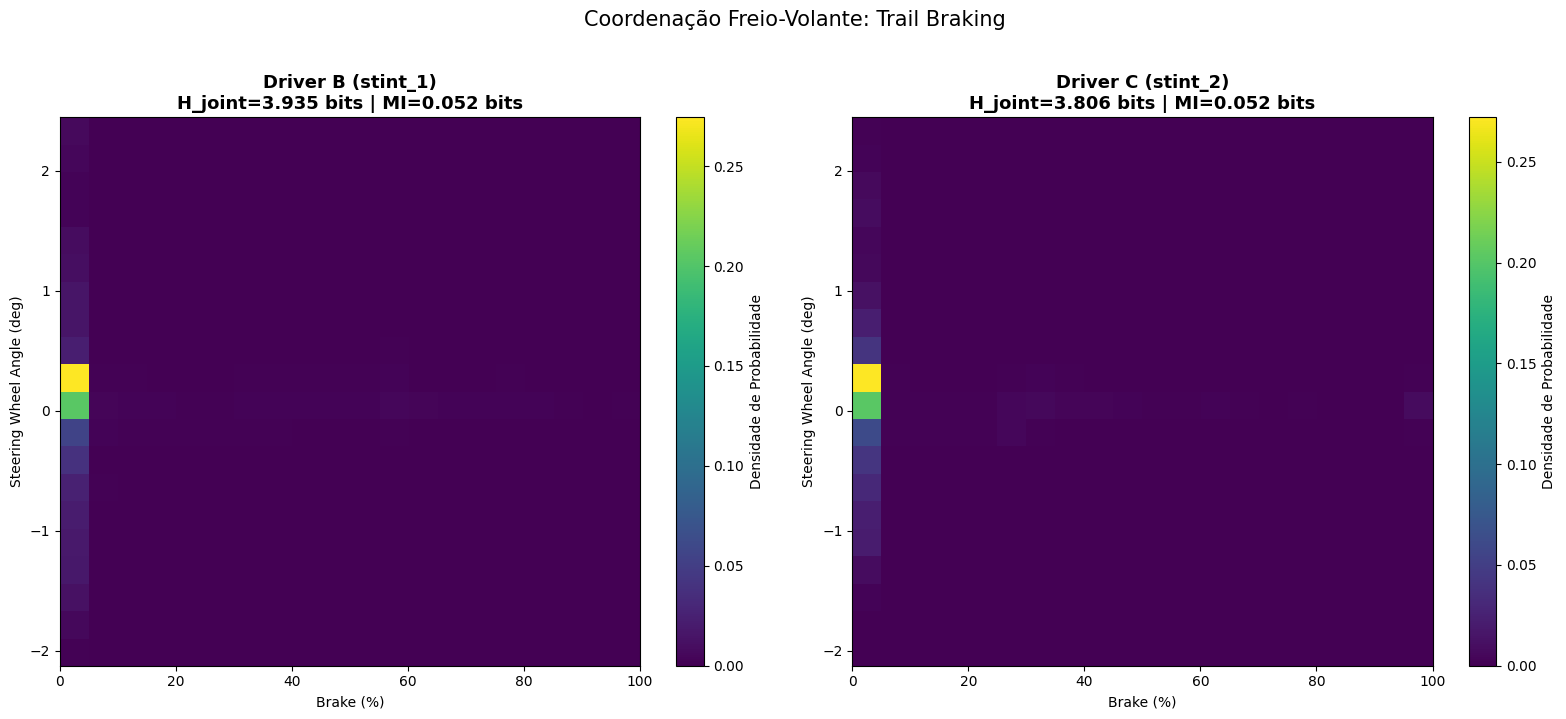

In [99]:
# --- VISUALIZAÇÃO: Histogramas 2D lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (label, stint, df) in zip(axes, [(driver_a, STINT_REF, df_ref_clean),
                                          (driver_b, STINT_TEST, df_test_clean)]):
    hist2d = results_joint[label]['hist2d']
    im = ax.imshow(
        hist2d.T, origin='lower', aspect='auto', cmap='viridis',
        extent=[brake_range[0], brake_range[1], steer_range[0], steer_range[1]]
    )
    ax.set_title(
        f"{label} ({stint})\nH_joint={results_joint[label]['h_joint']:.3f} bits | "
        f"MI={results_joint[label]['mi']:.3f} bits",
        fontsize=13, fontweight='bold'
    )
    ax.set_xlabel('Brake (%)')
    ax.set_ylabel('Steering Wheel Angle (deg)')
    fig.colorbar(im, ax=ax, label='Densidade de Probabilidade')

plt.suptitle('Coordenação Freio-Volante: Trail Braking', fontsize=15, y=1.02)
plt.tight_layout()

#file_name = f"joint_entropy_brake_steer_{driver_a}_vs_{driver_b}_{track_id}.png"
#fig.savefig(SAVE_DIR / file_name, dpi=300, bbox_inches='tight')
plt.show()

In [100]:
def add_sector_column(df):
    df = assign_sectors(df, CUSTOM_EDGES)  # já retorna df com coluna 'Sector' (inteiros 1..N)
    # mapeia sector numérico -> nome legível
    sector_map = {i + 1: name for i, name in enumerate(SECTOR_NAMES)}
    df['Sector'] = df['Sector'].map(sector_map)
    return df

df_ref_sec  = add_sector_column(df_ref_clean)
df_test_sec = add_sector_column(df_test_clean)

print(f"Setores disponíveis: {SECTOR_NAMES}")

Setores disponíveis: {1: 'T1 (Heartlands)', 2: 'T2', 3: 'T3 (Infield)', 4: 'T4', 5: 'T5/T6 Transition', 6: 'Hairpin Setup', 7: 'New Hairpin', 8: 'Oval Turn 1', 9: 'Oval Turn 2', 10: 'Backstretch', 11: 'Bus Stop Entry', 12: 'Bus Stop Apex', 13: 'Bus Stop Exit', 14: 'Oval Turn 3', 15: 'Oval Turn 4', 16: 'Final Chicane Entry', 17: 'Final Chicane Exit', 18: 'Frontstretch'}


In [101]:
def compute_joint_entropy_by_sector(df, brake_range, steer_range, bins=20, min_samples=30):
    rows = []
    # Itera sobre as CHAVES (funciona perfeitamente!)
    for sector in SECTOR_NAMES: 
        subset = df[df['Sector'] == sector]
        
        # 1. DROPNA CONJUNTO para garantir que as linhas de freio e volante sejam do mesmo instante de tempo
        cleaned_subset = subset[['Brake_Pct', 'SteeringWheelAngle']].dropna()
        
        brake = cleaned_subset['Brake_Pct'].values
        steer = cleaned_subset['SteeringWheelAngle'].values
        n = len(cleaned_subset)

        if n < min_samples:
            rows.append({'Sector': sector, 'H_joint': np.nan, 'H_brake': np.nan,
                         'H_steer': np.nan, 'MI': np.nan, 'N': n})
            continue

        hist2d, _, _ = np.histogram2d(brake, steer, bins=bins, range=[brake_range, steer_range])
        
        # 2. EVITA DIVISÃO POR ZERO caso os dados fujam do Range
        if hist2d.sum() == 0:
             rows.append({'Sector': sector, 'H_joint': np.nan, 'H_brake': np.nan,
                         'H_steer': np.nan, 'MI': np.nan, 'N': n})
             continue
             
        p_joint = hist2d / hist2d.sum()
        h_joint = entropy(p_joint.flatten() + 1e-10, base=2)

        counts_b, _ = np.histogram(brake, bins=bins, range=brake_range)
        counts_s, _ = np.histogram(steer, bins=bins, range=steer_range)
        
        p_b = counts_b / (counts_b.sum() + 1e-10)
        p_s = counts_s / (counts_s.sum() + 1e-10)
        
        h_b = entropy(p_b + 1e-10, base=2)
        h_s = entropy(p_s + 1e-10, base=2)
        mi = h_b + h_s - h_joint

        rows.append({'Sector': sector, 'H_joint': h_joint, 'H_brake': h_b,
                     'H_steer': h_s, 'MI': mi, 'N': n})

    return pd.DataFrame(rows)


brake_range = global_ranges.get('Brake_Pct', (0, 100))
steer_range = global_ranges.get('SteeringWheelAngle')

df_sectors_ref  = compute_joint_entropy_by_sector(df_ref_sec,  brake_range, steer_range)
df_sectors_test = compute_joint_entropy_by_sector(df_test_sec, brake_range, steer_range)

df_sectors_ref['Driver']  = driver_a
df_sectors_test['Driver'] = driver_b

df_sectors_comparison = pd.concat([df_sectors_ref, df_sectors_test], ignore_index=True)
display(df_sectors_comparison)

,Sector,H_joint,H_brake,H_steer,MI,N,Driver
0,1,2.071055,1.245694e+00,0.987474,0.162113,6554,Driver B
1,2,2.862223,4.076150e-01,2.505293,0.050685,9356,Driver B
2,3,3.629306,8.993727e-01,2.875831,0.145897,6707,Driver B
3,4,4.251535,1.325778e+00,3.116829,0.191072,7719,Driver B
4,5,2.403629,6.585775e-08,2.403628,-0.000001,11682,Driver B
5,6,3.691506,9.551997e-01,2.917063,0.180757,13670,Driver B
6,7,5.551886,2.098296e+00,3.910460,0.456870,11613,Driver B
7,8,1.071486,6.585775e-08,1.071484,-0.000001,11065,Driver B
8,9,0.090067,6.585775e-08,0.090066,-0.000001,10508,Driver B
9,10,0.431217,6.585775e-08,0.431216,-0.000001,7097,Driver B


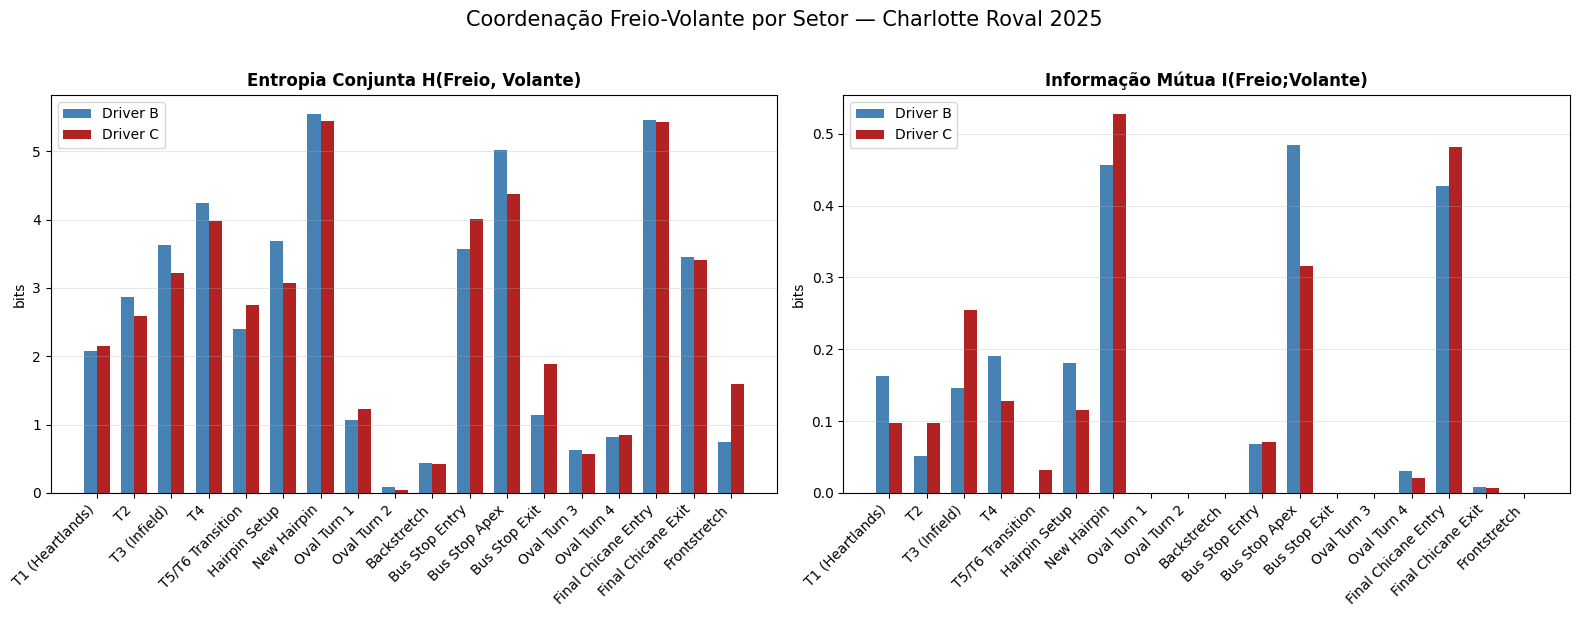

In [102]:
import numpy as np
import matplotlib.pyplot as plt

# --- VISUALIZAÇÃO: H_joint e MI por setor, comparando os dois pilotos ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CORREÇÃO AQUI: Iterar sobre as chaves (exatamente como foi feito na função de cálculo)
# Se SECTOR_NAMES for dict, isso pega as chaves. Se for lista, pega os itens.
sector_keys = list(SECTOR_NAMES) 

x = np.arange(len(sector_keys))
width = 0.35

for ax, metric, title in zip(axes, ['H_joint', 'MI'],
                              ['Entropia Conjunta H(Freio, Volante)', 'Informação Mútua I(Freio;Volante)']):
    
    # Extrai os valores usando as chaves corretas que existem no DataFrame
    vals_ref  = df_sectors_ref.set_index('Sector').reindex(sector_keys)[metric].values
    vals_test = df_sectors_test.set_index('Sector').reindex(sector_keys)[metric].values

    ax.bar(x - width/2, vals_ref,  width, label=driver_a, color='steelblue')
    ax.bar(x + width/2, vals_test, width, label=driver_b, color='firebrick')

    ax.set_xticks(x)
    
    # DICA VISUAL: Se SECTOR_NAMES for um dicionário e você quiser que o gráfico 
    # mostre os nomes bonitos (ex: "Curva 1") no eixo X em vez das chaves ("S1"), faça isso:
    if isinstance(SECTOR_NAMES, dict):
        display_labels = [SECTOR_NAMES[k] for k in sector_keys]
    else:
        display_labels = sector_keys
        
    ax.set_xticklabels(display_labels, rotation=45, ha='right')
    
    ax.set_ylabel('bits')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle(f'Coordenação Freio-Volante por Setor — {TRACK_NAME}', fontsize=15, y=1.02)
plt.tight_layout()

plt.show()

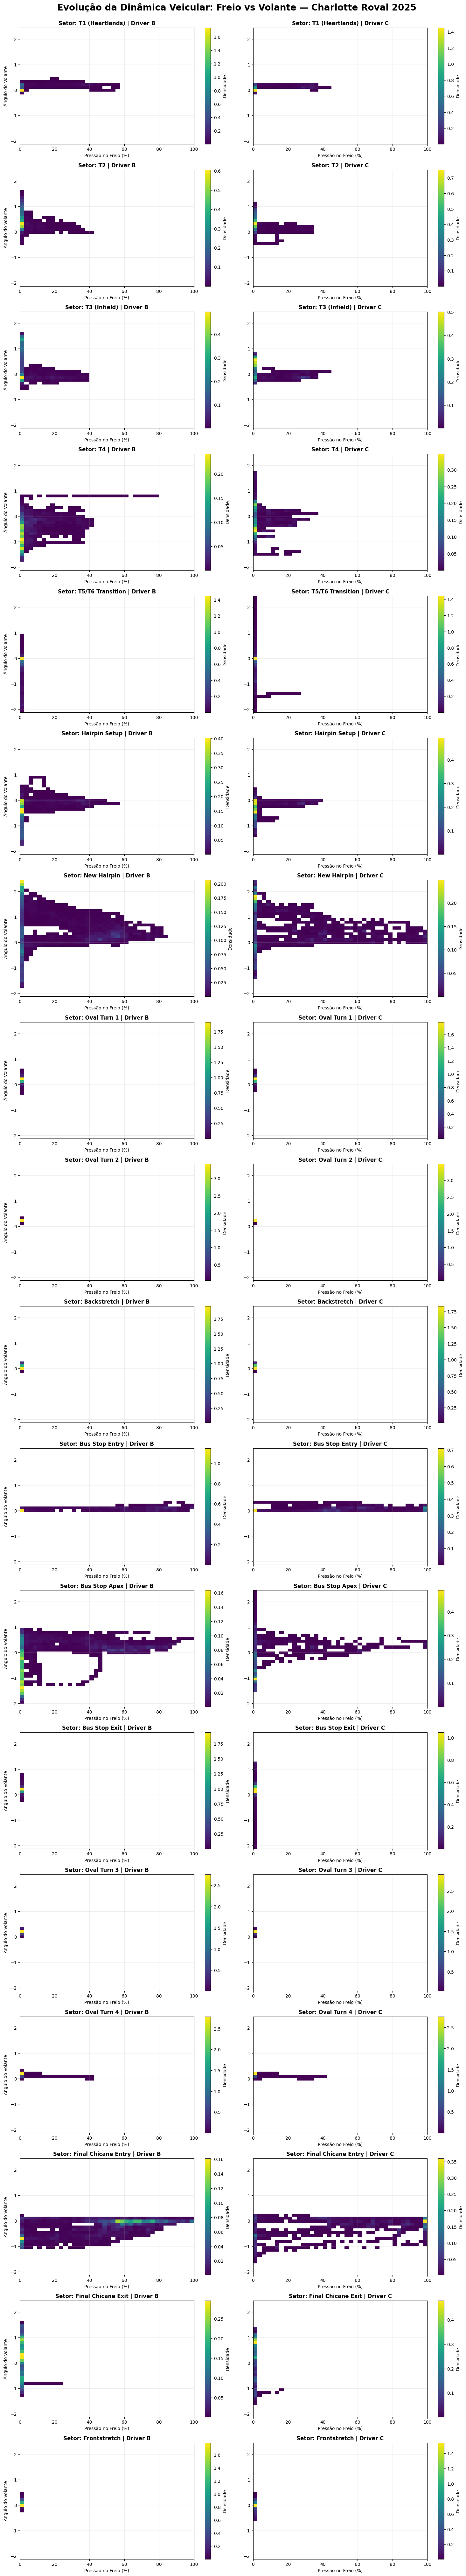

In [103]:
import numpy as np
import matplotlib.pyplot as plt

def plot_all_sectors_heatmaps(df_ref, df_test, sector_names, brake_range, steer_range, 
                              driver_a_name, driver_b_name, bins=40):
    """
    Gera uma grade de heatmaps 2D (Freio vs Volante) para TODOS os setores,
    comparando Piloto A (esquerda) e Piloto B (direita) linha a linha.
    """
    # 1. Trata SECTOR_NAMES para pegar as chaves e os nomes de exibição
    if isinstance(sector_names, dict):
        sector_keys = list(sector_names.keys())
        get_name = lambda k: sector_names[k]
    else:
        sector_keys = list(sector_names)
        get_name = lambda k: k
        
    n_sectors = len(sector_keys)
    
    # 2. Cria a figura: N linhas (setores) x 2 colunas (pilotos)
    # A altura (figsize) cresce dinamicamente (4 polegadas por setor)
    fig, axes = plt.subplots(nrows=n_sectors, ncols=2, figsize=(15, 4.5 * n_sectors))
    
    # Se houver apenas 1 setor, o matplotlib não retorna uma matriz 2D de axes. Isso corrige:
    if n_sectors == 1:
        axes = np.array([axes])
        
    # 3. Loop através de cada setor para popular os gráficos
    for i, sector_key in enumerate(sector_keys):
        display_name = get_name(sector_key)
        
        # Eixos da linha atual (i)
        ax_ref = axes[i, 0]
        ax_test = axes[i, 1]
        
        # Filtra e limpa os dados do setor atual, garantindo o sincronismo temporal
        subset_ref = df_ref[df_ref['Sector'] == sector_key][['Brake_Pct', 'SteeringWheelAngle']].dropna()
        subset_test = df_test[df_test['Sector'] == sector_key][['Brake_Pct', 'SteeringWheelAngle']].dropna()
        
        # --- PLOT PILOTO A (Esquerda) ---
        if len(subset_ref) >= 10:
            h1 = ax_ref.hist2d(subset_ref['Brake_Pct'], subset_ref['SteeringWheelAngle'], 
                               bins=bins, range=[brake_range, steer_range], 
                               cmap='viridis', density=True, cmin=1e-8)
            fig.colorbar(h1[3], ax=ax_ref, label='Densidade')
        else:
            ax_ref.text(0.5, 0.5, 'Dados Insuficientes', ha='center', va='center', 
                        transform=ax_ref.transAxes, color='red')
            
        # --- PLOT PILOTO B (Direita) ---
        if len(subset_test) >= 10:
            h2 = ax_test.hist2d(subset_test['Brake_Pct'], subset_test['SteeringWheelAngle'], 
                                bins=bins, range=[brake_range, steer_range], 
                                cmap='viridis', density=True, cmin=1e-8)
            fig.colorbar(h2[3], ax=ax_test, label='Densidade')
        else:
            ax_test.text(0.5, 0.5, 'Dados Insuficientes', ha='center', va='center', 
                         transform=ax_test.transAxes, color='red')
            
        # Formatação e Labels da linha
        ax_ref.set_title(f"Setor: {display_name} | {driver_a_name}", fontweight='bold')
        ax_test.set_title(f"Setor: {display_name} | {driver_b_name}", fontweight='bold')
        
        ax_ref.set_ylabel('Ângulo do Volante')
        ax_ref.set_xlabel('Pressão no Freio (%)')
        ax_test.set_xlabel('Pressão no Freio (%)')
        
        ax_ref.grid(alpha=0.2)
        ax_test.grid(alpha=0.2)

    # Título Global e Ajuste de Espaçamento
    plt.suptitle(f'Evolução da Dinâmica Veicular: Freio vs Volante — {TRACK_NAME}', 
                 fontsize=20, fontweight='bold', y=1.0 - (0.01 / max(1, n_sectors)))
    plt.tight_layout()
    plt.show()

# --- COMO EXECUTAR ---
# Recupera os limites globais dos sensores (como você já tem no seu código)
brake_range = global_ranges.get('Brake_Pct', (0, 100))
steer_range = global_ranges.get('SteeringWheelAngle', (-180, 180)) 

# Executa a plotagem para todos os setores
plot_all_sectors_heatmaps(
    df_ref=df_ref_sec, 
    df_test=df_test_sec, 
    sector_names=SECTOR_NAMES, 
    brake_range=brake_range, 
    steer_range=steer_range, 
    driver_a_name=driver_a, 
    driver_b_name=driver_b,
    bins=40 # Resolução do heatmap
)

In [104]:
# =========================================================
# PROCESSAMENTO, LIMPEZA E SELEÇÃO DA VOLTA MAIS RÁPIDA
# =========================================================

# 1. Limpeza básica e conversão de unidades
df_ref_proc  = basic_clean_and_units(df_ref)
df_test_proc = basic_clean_and_units(df_test)

# 2. Geração das tabelas de validade nomeadas
laps_ref  = build_lap_validity_table(df_ref_proc, manual_invalid={}, max_lap_time_s=115.0)
laps_test = build_lap_validity_table(df_test_proc, max_lap_time_s=115.0)

laps_ref['LapTime_Formatted']  = laps_ref['LapTime_s'].apply(format_laptime)
laps_test['LapTime_Formatted'] = laps_test['LapTime_s'].apply(format_laptime)

# 3. ENCONTRAR O NÚMERO DA VOLTA MAIS RÁPIDA (Apenas entre as válidas)
valid_laps_ref  = laps_ref[laps_ref["Valid"]]
valid_laps_test = laps_test[laps_test["Valid"]]

# Encontra a linha com o menor tempo em segundos
best_lap_row_ref  = valid_laps_ref.loc[valid_laps_ref['LapTime_s'].idxmin()]
best_lap_row_test = valid_laps_test.loc[valid_laps_test['LapTime_s'].idxmin()]

best_lap_num_ref  = best_lap_row_ref['Lap']
best_lap_num_test = best_lap_row_test['Lap']

print(f"⏱️ Volta mais rápida de {driver_a}: Volta {best_lap_num_ref} com o tempo de {best_lap_row_ref['LapTime_Formatted']}")
print(f"⏱️ Volta mais rápida de {driver_b}: Volta {best_lap_num_test} com o tempo de {best_lap_row_test['LapTime_Formatted']}")
print("-" * 60)

# 4. FILTRAR O DATASET ORIGINAL APENAS PARA A MELHOR VOLTA DE CADA UM
df_ref_clean  = df_ref_proc[df_ref_proc["Lap"] == best_lap_num_ref].copy()
df_test_clean = df_test_proc[df_test_proc["Lap"] == best_lap_num_test].copy()

# --- Relatório de Conferência ---
print(f"✅ Dataframe de {driver_a} pronto para análise (Apenas Volta {best_lap_num_ref}). Total de linhas: {len(df_ref_clean)}")
print(f"✅ Dataframe de {driver_b} pronto para análise (Apenas Volta {best_lap_num_test}). Total de linhas: {len(df_test_clean)}")

──────────────────────────────────────────────────────────────
  Lap Validity Report  (29 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 25 laps
  🏆 Fastest : Lap 19  (01:36.733)
  ❌ Invalid : 4 laps
     Lap   0  48:37.467  → FracLowSpeed=0.30 | LapTime=2917.5s | GPS=95.0%<100%
     Lap   5  01:40.250  → IQR_outlier
     Lap  10  01:48.733  → IQR_outlier
     Lap  28  02:57.883  → FracLowSpeed=0.44 | LapTime=177.9s
──────────────────────────────────────────────────────────────
──────────────────────────────────────────────────────────────
  Lap Validity Report  (19 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 12 laps
  🏆 Fastest : Lap 29  (01:38.417)
  ❌ Invalid : 7 laps
     Lap   0  00:00.000  → CompletedPct=0.000<0.995 | FracLowSpeed=1.00 | MaxSpeed=0.0kph | LapTime=0.0s | GPS=1.0%<100%
     Lap  14  01:57.500  → StartPct=0.065>0.02 | LapTime=117.5s | GPS=94.0%<100%
     Lap  20  01:56.200  → LapT

⏱️ Analisando apenas a melhor volta de Driver B: Volta 19
⏱️ Analisando apenas a melhor volta de Driver C: Volta 29
----------------------------------------------------------------------
📌 Setores filtrados com sucesso para a melhor volta.
📊 Gerando os Heatmaps Comparativos da Volta Mais Rápida...


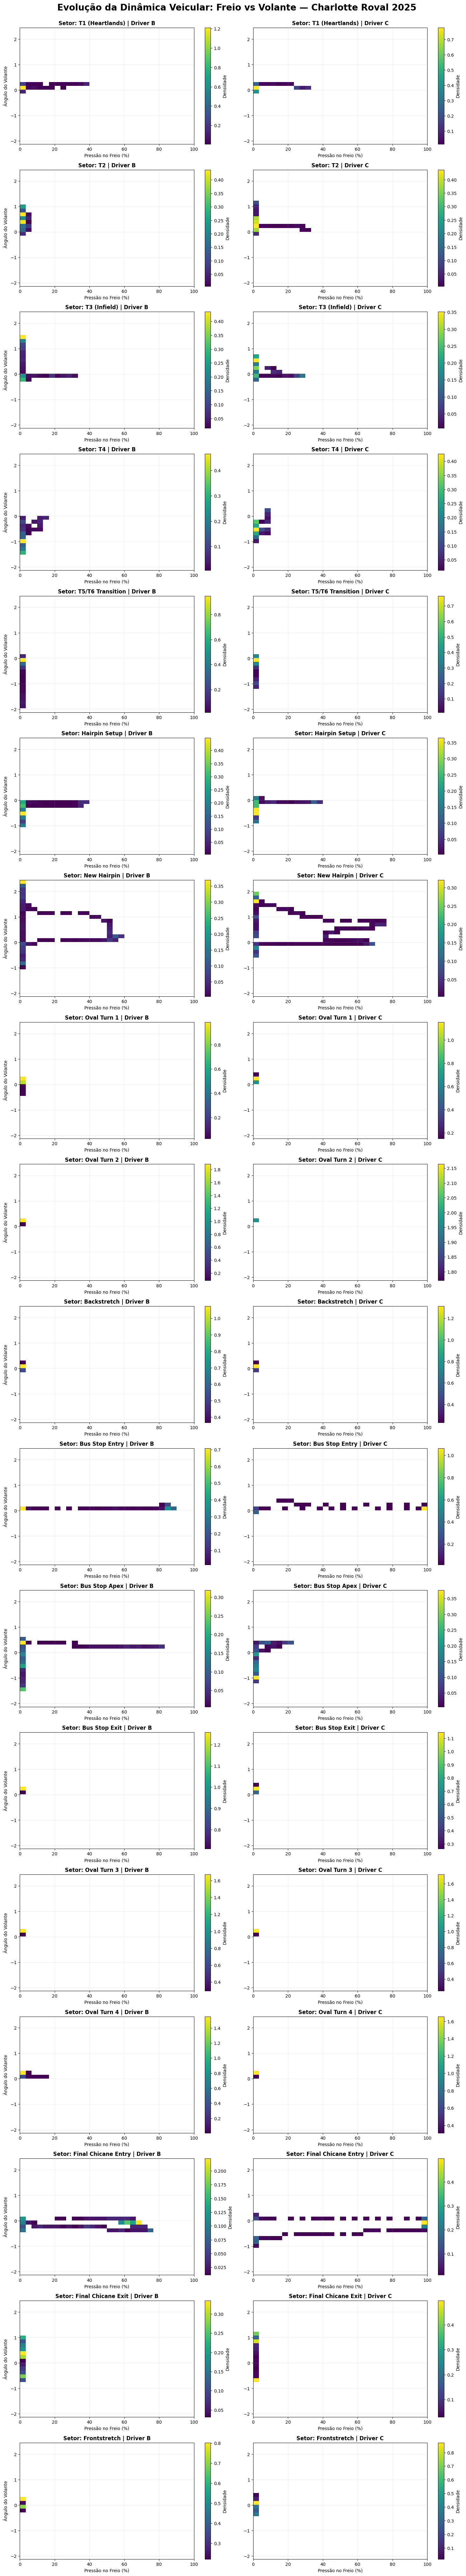

In [ ]:
# ==============================================================================
# STEP 1: FILTRAR A VOLTA MAIS RÁPIDA DE CADA UM (Mantido igual)
# ==============================================================================
valid_laps_ref  = laps_ref[laps_ref["Valid"]]
valid_laps_test = laps_test[laps_test["Valid"]]

best_lap_num_ref  = valid_laps_ref.loc[valid_laps_ref['LapTime_s'].idxmin()]['Lap']
best_lap_num_test = valid_laps_test.loc[valid_laps_test['LapTime_s'].idxmin()]['Lap']

df_best_ref  = df_ref_proc[df_ref_proc["Lap"] == best_lap_num_ref].copy()
df_best_test = df_test_proc[df_test_proc["Lap"] == best_lap_num_test].copy()

print(f"⏱️ Analisando apenas a melhor volta de {driver_a}: Volta {best_lap_num_ref}")
print(f"⏱️ Analisando apenas a melhor volta de {driver_b}: Volta {best_lap_num_test}")
print("-" * 70)


# ==============================================================================
# STEP 2: PUXAR A COLUNA 'Sector' DOS DATAFRAMES JÁ MAPEADOS
# ==============================================================================
# Como df_ref_sec e df_test_sec já possuem a coluna 'Sector' gerada anteriormente
# no seu notebook, nós apenas filtramos eles usando o número da melhor volta:

df_ref_sec_best  = df_ref_sec[df_ref_sec["Lap"] == best_lap_num_ref].copy()
df_test_sec_best = df_test_sec[df_test_sec["Lap"] == best_lap_num_test].copy()

print("📌 Setores filtrados com sucesso para a melhor volta.")


# ==============================================================================
# STEP 3: RECALCULAR A ENTROPIA CONJUNTA E INFORMAÇÃO MÚTUA
# ==============================================================================
brake_range = global_ranges.get('Brake_Pct', (0, 100))
steer_range = global_ranges.get('SteeringWheelAngle', (-180, 180))

df_sectors_ref_best  = compute_joint_entropy_by_sector(df_ref_sec_best, brake_range, steer_range, min_samples=10)
df_sectors_test_best = compute_joint_entropy_by_sector(df_test_sec_best, brake_range, steer_range, min_samples=10)

df_sectors_ref_best['Driver']  = driver_a
df_sectors_test_best['Driver'] = driver_b


# ==============================================================================
# STEP 4: GERAR OS SUBPLOTS DOS HEATMAPS PARA A MELHOR VOLTA
# ==============================================================================
print("📊 Gerando os Heatmaps Comparativos da Volta Mais Rápida...")
"""
plot_all_sectors_heatmaps(
    df_ref=df_ref_sec_best, 
    df_test=df_test_sec_best, 
    sector_names=SECTOR_NAMES, 
    brake_range=brake_range, 
    steer_range=steer_range, 
    driver_a_name=driver_a, 
    driver_b_name=driver_b,
    bins=30 # Diminuí ligeiramente os bins para 30 para compensar termos menos pontos por ser uma só volta
)
"""

In [109]:
# ============================================================
# NOVA ANÁLISE: BrakeRampRate — JSD + PE (forma vs. magnitude)
# Adicionar após o bloco de cálculo de entropia por canal existente
# ============================================================

import numpy as np
from scipy.signal import savgol_filter
from scipy.spatial.distance import jensenshannon
import antropy as ant

BINS = 20  # mesmo padrão global do restante do artigo (H_max fixo)

def compute_brake_ramp_rate_df(df: pd.DataFrame,
                                brake_col: str = "Brake_Pct",
                                time_col: str = "SessionTime") -> np.ndarray:
    """
    Versão para DataFrame (compatível com df_ref_clean / df_test_clean
    já existentes no joint_entropy.ipynb).
    """
    d = df.sort_values(time_col)
    brake = d[brake_col].to_numpy()
    t_rel = d[time_col].to_numpy()
    return compute_brake_ramp_rate(brake, t_rel)


def compare_brake_ramp_rate_df(df_A: pd.DataFrame, df_B: pd.DataFrame,
                                label_A: str, label_B: str,
                                brake_col: str = "Brake_Pct",
                                time_col: str = "SessionTime") -> dict:
    rate_A = compute_brake_ramp_rate_df(df_A, brake_col, time_col)
    rate_B = compute_brake_ramp_rate_df(df_B, brake_col, time_col)

    jsd_val = jsd_fixed_bins(rate_A, rate_B, bins=BINS)
    pe_A = pe_from_series(rate_A)
    pe_B = pe_from_series(rate_B)

    return {
        "Driver_A": label_A,
        "Driver_B": label_B,
        "JSD_BrakeRampRate": jsd_val,
        "PE_BrakeRampRate_A": pe_A,
        "PE_BrakeRampRate_B": pe_B,
        "Delta_PE": pe_B - pe_A,
        "BrakePeak_A": float(df_A[brake_col].max()),
        "BrakePeak_B": float(df_B[brake_col].max()),
    }


def jsd_fixed_bins(x: np.ndarray, y: np.ndarray, bins: int = BINS) -> float:
    """
    JSD entre duas séries usando bins fixos e globais (comparabilidade
    cross-driver, mesma lógica do restante do pipeline de entropia).
    """
    lo = min(np.nanmin(x), np.nanmin(y))
    hi = max(np.nanmax(x), np.nanmax(y))
    edges = np.linspace(lo, hi, bins + 1)

    p, _ = np.histogram(x, bins=edges, density=False)
    q, _ = np.histogram(y, bins=edges, density=False)

    p = p / p.sum()
    q = q / q.sum()

    # jensenshannon do scipy retorna a distância (raiz do JSD);
    # elevar ao quadrado recupera o JSD em nats/bits conforme base=2
    dist = jensenshannon(p, q, base=2)
    return float(dist ** 2)


def pe_from_series(x: np.ndarray, m: int = 3, delay: int = 1) -> float:
    """
    Permutation Entropy — mesmos parâmetros usados na Seção 6.3
    (m=3, tau=1), normalizada entre 0 e 1.
    """
    return float(ant.perm_entropy(x, order=m, delay=delay, normalize=True))

def compute_sector_delta_time(df_ref_sec, df_test_sec, sector_names):
    """
    Calcula o tempo gasto (max - min SessionTime) por setor, para a
    melhor volta de cada piloto, e retorna o delta (B - A).
    """
    rows = []
    for sector in sector_names:
        t_ref  = df_ref_sec[df_ref_sec["Sector"] == sector]["SessionTime"]
        t_test = df_test_sec[df_test_sec["Sector"] == sector]["SessionTime"]

        if t_ref.empty or t_test.empty:
            continue

        time_a = t_ref.max() - t_ref.min()
        time_b = t_test.max() - t_test.min()

        rows.append({
            "Sector": sector,
            "SectorTime_A": time_a,
            "SectorTime_B": time_b,
            "DeltaTime_s": time_b - time_a
        })
    return pd.DataFrame(rows)





# ------------------------------------------------------------
# EXECUÇÃO — exemplo usando os dicts sec já existentes no notebook
# (ex: sec_raw de sector_heuristics, ou interp_A/interp_B recortados)
# ------------------------------------------------------------
result = compare_brake_ramp_rate_df(
    df_ref_clean, df_test_clean,
    label_A=driver_a, label_B=driver_b
)
print(result)

rows = []
for sector in SECTOR_NAMES:
    sub_ref  = df_ref_sec_best[df_ref_sec_best["Sector"] == sector]
    sub_test = df_test_sec_best[df_test_sec_best["Sector"] == sector]

    if len(sub_ref) < 10 or len(sub_test) < 10:
        continue

    r = compare_brake_ramp_rate_df(sub_ref, sub_test, driver_a, driver_b)
    r["Sector"] = sector
    rows.append(r)

df_brake_ramp_comparison = pd.DataFrame(rows)
display(df_brake_ramp_comparison)

# --- Junta o tempo perdido por setor ao dataframe de JSD/PE ---
df_sector_time = compute_sector_delta_time(df_ref_sec_best, df_test_sec_best, SECTOR_NAMES)
df_brake_ramp_comparison = df_brake_ramp_comparison.merge(
    df_sector_time[["Sector", "DeltaTime_s"]], on="Sector", how="left"
)

{'Driver_A': 'Driver B', 'Driver_B': 'Driver C', 'JSD_BrakeRampRate': 0.003079491125995575, 'PE_BrakeRampRate_A': 0.22419755903963787, 'PE_BrakeRampRate_B': 0.21329197758518767, 'Delta_PE': -0.010905581454450197, 'BrakePeak_A': 88.60159516334534, 'BrakePeak_B': 100.0}


,Driver_A,Driver_B,JSD_BrakeRampRate,PE_BrakeRampRate_A,PE_BrakeRampRate_B,Delta_PE,BrakePeak_A,BrakePeak_B,Sector
0,Driver B,Driver C,0.110853,0.274492,0.426879,0.152387,39.977127,31.210479,1
1,Driver B,Driver C,0.033534,0.198356,0.225886,0.027530,5.425173,30.489728,2
2,Driver B,Driver C,0.046876,0.315766,0.324633,0.008867,31.453872,29.779163,3
3,Driver B,Driver C,0.031904,0.320615,0.436789,0.116174,14.176866,9.693114,4
4,Driver B,Driver C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5
5,Driver B,Driver C,0.037219,0.248550,0.307044,0.058493,38.067091,38.180238,6
6,Driver B,Driver C,0.043794,0.450972,0.420835,-0.030137,58.263934,74.258685,7
7,Driver B,Driver C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8
8,Driver B,Driver C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9
9,Driver B,Driver C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10


Saved: brake_ramp_rate_analysis_Driver B_vs_Driver C.png


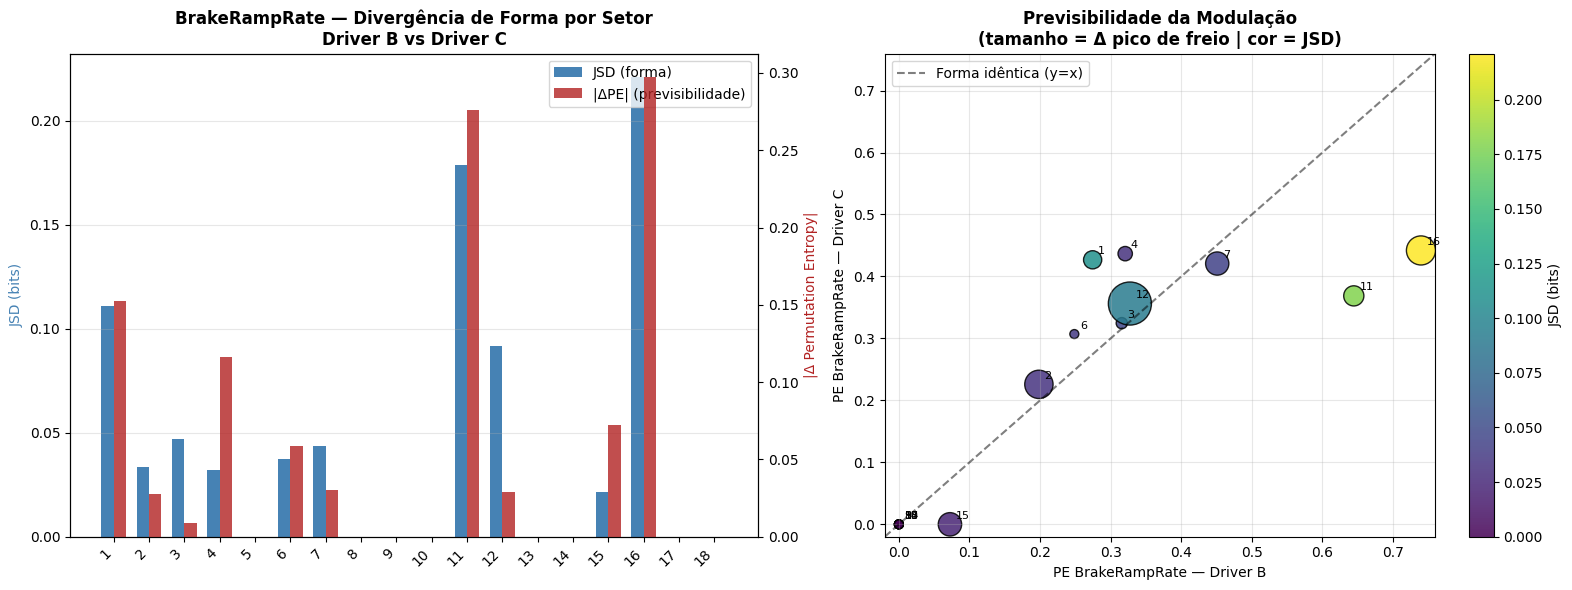

In [107]:
import matplotlib.pyplot as plt
import numpy as np

def plot_brake_ramp_analysis(df_cmp, driver_a, driver_b, track_name=None, save_dir=None):
    """
    Dashboard: JSD/Delta_PE por setor + scatter PE_A vs PE_B
    (tamanho do ponto = diferença de pico de freio).
    """
    df = df_cmp.copy()
    df["Abs_Delta_PE"] = df["Delta_PE"].abs()
    df["BrakePeak_Diff"] = (df["BrakePeak_B"] - df["BrakePeak_A"]).abs()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- PAINEL 1: JSD e |Delta_PE| por setor ---
    x = np.arange(len(df))
    width = 0.35

    ax1b = ax1.twinx()
    bars1 = ax1.bar(x - width/2, df["JSD_BrakeRampRate"], width,
                     color="steelblue", label="JSD (forma)")
    bars2 = ax1b.bar(x + width/2, df["Abs_Delta_PE"], width,
                      color="firebrick", alpha=0.8, label="|ΔPE| (previsibilidade)")

    ax1.set_xticks(x)
    ax1.set_xticklabels(df["Sector"], rotation=45, ha="right")
    ax1.set_ylabel("JSD (bits)", color="steelblue")
    ax1b.set_ylabel("|Δ Permutation Entropy|", color="firebrick")
    ax1.set_title(f"BrakeRampRate — Divergência de Forma por Setor\n{driver_a} vs {driver_b}",
                  fontweight="bold")
    ax1.grid(True, axis="y", alpha=0.3)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1b.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    # --- PAINEL 2: Scatter PE_A vs PE_B (diagonal = forma idêntica) ---
    sc = ax2.scatter(df["PE_BrakeRampRate_A"], df["PE_BrakeRampRate_B"],
                      s=df["BrakePeak_Diff"] * 15 + 40,   # tamanho ~ diferença de pico
                      c=df["JSD_BrakeRampRate"], cmap="viridis",
                      edgecolor="black", alpha=0.85)

    lims = [
        min(df["PE_BrakeRampRate_A"].min(), df["PE_BrakeRampRate_B"].min()) - 0.02,
        max(df["PE_BrakeRampRate_A"].max(), df["PE_BrakeRampRate_B"].max()) + 0.02
    ]
    ax2.plot(lims, lims, "k--", alpha=0.5, label="Forma idêntica (y=x)")
    ax2.set_xlim(lims); ax2.set_ylim(lims)

    for _, row in df.iterrows():
        ax2.annotate(str(row["Sector"]), (row["PE_BrakeRampRate_A"], row["PE_BrakeRampRate_B"]),
                     fontsize=8, xytext=(4, 4), textcoords="offset points")

    ax2.set_xlabel(f"PE BrakeRampRate — {driver_a}")
    ax2.set_ylabel(f"PE BrakeRampRate — {driver_b}")
    ax2.set_title("Previsibilidade da Modulação\n(tamanho = Δ pico de freio | cor = JSD)",
                  fontweight="bold")
    ax2.legend(loc="upper left")
    ax2.grid(True, alpha=0.3)
    fig.colorbar(sc, ax=ax2, label="JSD (bits)")

    plt.tight_layout()

    if save_dir is not None:
        fname = f"brake_ramp_rate_analysis_{driver_a}_vs_{driver_b}.png"
        fig.savefig(Path(save_dir) / fname, dpi=300, bbox_inches="tight")
        print(f"Saved: {fname}")

    plt.show()

# --- EXECUÇÃO ---
plot_brake_ramp_analysis(df_brake_ramp_comparison, driver_a, driver_b,
                          track_name=TRACK_NAME, save_dir=SAVE_DIR)

Saved: brake_ramp_rate_analysis_Driver B_vs_Driver C.png


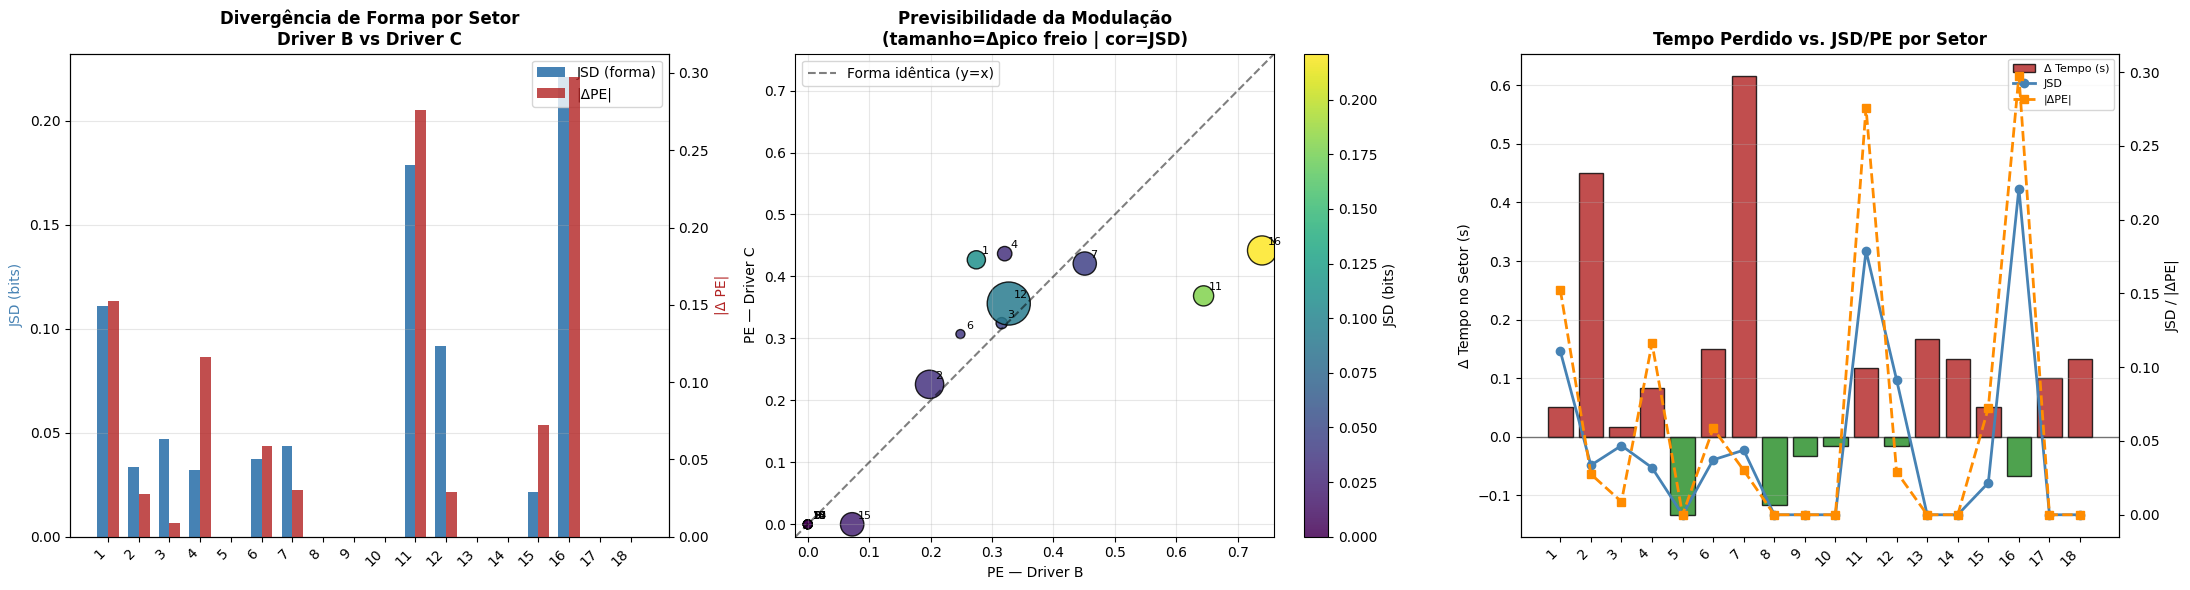

In [111]:
def plot_brake_ramp_analysis(df_cmp, driver_a, driver_b, track_name=None, save_dir=None):
    df = df_cmp.copy()
    df["Abs_Delta_PE"] = df["Delta_PE"].abs()
    df["BrakePeak_Diff"] = (df["BrakePeak_B"] - df["BrakePeak_A"]).abs()

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

    # --- PAINEL 1: JSD e |Delta_PE| por setor ---
    x = np.arange(len(df))
    width = 0.35
    ax1b = ax1.twinx()
    ax1.bar(x - width/2, df["JSD_BrakeRampRate"], width, color="steelblue", label="JSD (forma)")
    ax1b.bar(x + width/2, df["Abs_Delta_PE"], width, color="firebrick", alpha=0.8, label="|ΔPE|")
    ax1.set_xticks(x); ax1.set_xticklabels(df["Sector"], rotation=45, ha="right")
    ax1.set_ylabel("JSD (bits)", color="steelblue")
    ax1b.set_ylabel("|Δ PE|", color="firebrick")
    ax1.set_title(f"Divergência de Forma por Setor\n{driver_a} vs {driver_b}", fontweight="bold")
    ax1.grid(True, axis="y", alpha=0.3)
    l1, la1 = ax1.get_legend_handles_labels(); l2, la2 = ax1b.get_legend_handles_labels()
    ax1.legend(l1 + l2, la1 + la2, loc="upper right")

    # --- PAINEL 2: Scatter PE_A vs PE_B ---
    sc = ax2.scatter(df["PE_BrakeRampRate_A"], df["PE_BrakeRampRate_B"],
                      s=df["BrakePeak_Diff"] * 15 + 40,
                      c=df["JSD_BrakeRampRate"], cmap="viridis",
                      edgecolor="black", alpha=0.85)
    lims = [min(df["PE_BrakeRampRate_A"].min(), df["PE_BrakeRampRate_B"].min()) - 0.02,
            max(df["PE_BrakeRampRate_A"].max(), df["PE_BrakeRampRate_B"].max()) + 0.02]
    ax2.plot(lims, lims, "k--", alpha=0.5, label="Forma idêntica (y=x)")
    ax2.set_xlim(lims); ax2.set_ylim(lims)
    for _, row in df.iterrows():
        ax2.annotate(str(row["Sector"]), (row["PE_BrakeRampRate_A"], row["PE_BrakeRampRate_B"]),
                     fontsize=8, xytext=(4, 4), textcoords="offset points")
    ax2.set_xlabel(f"PE — {driver_a}"); ax2.set_ylabel(f"PE — {driver_b}")
    ax2.set_title("Previsibilidade da Modulação\n(tamanho=Δpico freio | cor=JSD)", fontweight="bold")
    ax2.legend(loc="upper left"); ax2.grid(True, alpha=0.3)
    fig.colorbar(sc, ax=ax2, label="JSD (bits)")

    # --- PAINEL 3: DeltaTime_s por setor (barras) + JSD sobreposto (linha) ---
    valid = df.dropna(subset=["DeltaTime_s"]).reset_index(drop=True)
    xt = np.arange(len(valid))

    colors_dt = ["firebrick" if v > 0 else "forestgreen" for v in valid["DeltaTime_s"]]
    ax3.bar(xt, valid["DeltaTime_s"], color=colors_dt, edgecolor="black", alpha=0.8,
            label="Δ Tempo (s)")
    ax3.axhline(0, color="black", linewidth=1, alpha=0.5)
    ax3.set_xticks(xt); ax3.set_xticklabels(valid["Sector"], rotation=45, ha="right")
    ax3.set_ylabel("Δ Tempo no Setor (s)")

    ax3b = ax3.twinx()
    ax3b.plot(xt, valid["JSD_BrakeRampRate"], color="steelblue", marker="o",
              linewidth=2, label="JSD")
    ax3b.plot(xt, valid["Abs_Delta_PE"], color="darkorange", marker="s",
              linewidth=2, linestyle="--", label="|ΔPE|")
    ax3b.set_ylabel("JSD / |ΔPE|")

    ax3.set_title("Tempo Perdido vs. JSD/PE por Setor", fontweight="bold")
    ax3.grid(True, axis="y", alpha=0.3)
    l3, la3 = ax3.get_legend_handles_labels(); l3b, la3b = ax3b.get_legend_handles_labels()
    ax3.legend(l3 + l3b, la3 + la3b, loc="upper right", fontsize=8)

    plt.tight_layout()

    if save_dir is not None:
        fname = f"brake_ramp_rate_analysis_{driver_a}_vs_{driver_b}.png"
        fig.savefig(Path(save_dir) / fname, dpi=300, bbox_inches="tight")
        print(f"Saved: {fname}")

    plt.show()

# --- EXECUÇÃO ---
plot_brake_ramp_analysis(df_brake_ramp_comparison, driver_a, driver_b,
                          track_name=TRACK_NAME, save_dir=SAVE_DIR)